<h1 style="text-align: center;">Arabic Dialect Identification<h1>

Prepare libraries

In [39]:
import os
import nltk
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from nltk.tokenize import TweetTokenizer
from nltk.collocations import BigramAssocMeasures, BigramCollocationFinder, TrigramAssocMeasures, TrigramCollocationFinder
import re
import itertools
from collections import Counter
from wordcloud import WordCloud
from arabic_reshaper import arabic_reshaper
from bidi.algorithm import get_display
from nltk import ngrams
import emoji
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, jaccard_score, confusion_matrix, ConfusionMatrixDisplay
from gensim.models import KeyedVectors
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
import seaborn as sns
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from itertools import combinations
from sklearn.manifold import TSNE

# مهمة 01  : تحميل البيانات

## [1.1]

<div dir="rtl">الكود التالي يقوم بتحميل مجموعتي البيانات madar و qadi وعرض عدد العينات الكلي وأول عشر أسطر<div>

In [2]:
folder_path='madar_files'
madar_files = [os.path.join(folder_path, file) for file in os.listdir(folder_path)]
madar_dataframes = [pd.read_csv(file, sep='\t') for file in madar_files]
merged_madar = pd.concat(madar_dataframes, ignore_index=True)

qadi_train= pd.read_parquet('train.parquet')
qadi_validation= pd.read_parquet('validation.parquet')
qadi_test= pd.read_parquet('test.parquet')

#في هذه الجزئية من الكود سنقوم بتبديل رقم الدولة باسمها في هذه المجموعة وذلك سيساعد من أجل الدمج لاحقاً وإضافة عمود المنطقة
country_mapping = {
    0: 'OM', 1: 'SD', 2: 'SA', 3: 'KW', 4: 'QA', 5: 'LB', 6: 'JO', 7: 'SY', 8: 'IQ', 9: 'MA',
    10: 'EG', 11: 'PL', 12: 'YE', 13: 'BH', 14: 'DZ', 15: 'AE', 16: 'TN', 17: 'LY'
}
qadi_train['label']=qadi_train['label'].map(country_mapping)
qadi_validation['label']=qadi_validation['label'].map(country_mapping)
qadi_test['label']=qadi_test['label'].map(country_mapping)

qadi=[qadi_train,qadi_validation,qadi_test]
merged_qadi= pd.concat(qadi)


In [75]:
print("total elements im Madar:::>",merged_madar.shape)
merged_madar.head(10)

total elements im Madar:::> (112000, 4)


,sentID.BTEC,split,lang,sent
0,5,corpus-6-test-corpus-26-train,ALE,هو هنيك، قدام معلومات السياح بالضبط.
1,9,corpus-6-test-corpus-26-train,ALE,مالي سمعان من قبل بهالعنوان هون.
2,11,corpus-6-test-corpus-26-train,ALE,روح ساوي لبين ما تشوف صيدلية.
3,26,corpus-6-test-corpus-26-train,ALE,بشقد الفطور؟
4,27,corpus-6-test-corpus-26-train,ALE,شلون بقدر أساعدك؟
5,30,corpus-6-test-corpus-26-train,ALE,روح عاليسار عند تالت مفرق.
6,50,corpus-6-test-corpus-26-train,ALE,بتريد كريمة وسكر بقهوتك؟
7,64,corpus-6-test-corpus-26-train,ALE,خرج تصرفلي شيك الميتين دولار تبعي؟
8,74,corpus-6-test-corpus-26-train,ALE,إذا لازم يبين، اتصل فيني إذا سمحت.
9,86,corpus-6-test-corpus-26-train,ALE,وين الكافيه؟


In [76]:
print("total elements im Qadi:::>",merged_qadi.shape)
merged_qadi.head(10)

total elements im Qadi:::> (458197, 3)


,id,label,text
0,1046024946705735552,MA,@Ahmed_Hamza27 اتمنى صراحة و خصوصا #طال_عمره ب...
1,1140189387508134016,LY,@rJiM4CnIFTgml9g @zamnissi طبعا عرفته من اللي ...
2,1051416181855440768,OM,@OmanisFollowers @ooredoo @TRA_OMAN @motc_om ه...
3,781770259422412800,PL,كلب شو كنتوا بتتوقعوا منه !؟ \n\nمحمود عباس لا...
4,968140551366340608,PL,#عزام 🔊\nاحنا ابو الولد وام الولد
5,1129830890069270400,SA,@HussamAAlsaleh1 الله يبشرررررك بالجنة يابو سع...
6,1055146289791258624,QA,@Ocxoc @AlArabiya_Brk والله العظيم انه مجرد تق...
7,1040998864327794816,LY,@anasyounis52 اها مستوى أقل شوية هههههههه
8,966103834618744832,EG,قلبي مقبوض ، بقالي كام يوم مش متظبط و اتمني ان...
9,1126962565261811584,SA,@ryanovic_nfc خوينا ذا 😒 مانخلي اخويانا


<div dir="rtl">الكود التالي نتحقق من أجل كل مجموعة في Madar وكل مجموعة في Qadi إن كان هناك اسطر فارغة أو Nan أو تكرارات</div>

In [59]:
#check for Nan
print("Nan Madar:")
print(merged_madar.isna().sum())
print ("\nNan Qadi:")
print (merged_qadi.isna().sum())

#check for null
print("\nNull Madar:")
print (merged_madar.isnull().sum())
print("\nNull Qadi:")
print (merged_qadi.isnull().sum())

#check for duplicates 
print("\nQadi Duplicates")
print(merged_qadi.duplicated().any())
print("\nMadar Duplicates")
print(merged_madar.duplicated().any())

Nan Madar:
sentID.BTEC    0
split          0
lang           0
sent           0
dtype: int64

Nan Qadi:
id       0
label    0
text     0
dtype: int64

Null Madar:
sentID.BTEC    0
split          0
lang           0
sent           0
dtype: int64

Null Qadi:
id       0
label    0
text     0
dtype: int64

Qadi Duplicates
False

Madar Duplicates
False


<div dir="rtl">نلاحظ أنه لا يوجد أي تكرارات أو قيم فارغة أو قيم Nan في كلا المجموعتين<div>

<div dir="rtl">الكود التالي يقوم بإعادة تسمية الحقل الموجود في مجموعة Madar ب city وإعادة تسمية الحقل الموجود بمجموعة qadi ب Country<div>
<div dir="rtl">ثم قراءة ملف الاكسل الذي يربط اسماء المنطقة بالبلد بالمدينة مع ملاحظة أننا عدلنا أسماء الأعمدة في الملف المرفق <div>
<div dir="rtl">ثم إضافة حقل Region و Country لمجموعة Madar وحقل Region لمجموعة Qadi<div>
<div dir="rtl">وبهذا يصبح لدينا مجموعة Madar مصنفة حسب المدينة والبلد والمنطقة ومجموعة Qadi  مصنفة حسب البلد والمنطقة<div>

## [1.2]

In [3]:
# قراءة ملف الاكسل الذي يربط اللهجة بالمنطقة والمدينة والبلد
# **************مع ملاحظة اننا غيرنا في تسمية عواميد الجدول من الملف وليس في الكود**********************
dialect_name_unification= pd.read_excel('dialect_name_unification.xlsx')

# إنشاء ماب تربط المدينة بالمنطقة وماب تربط المدينة بالبلد وماب تربط البلد بالمنطقة
city_region_mapping= dict(zip(dialect_name_unification['City Abbriviation'].dropna(), dialect_name_unification['Region English name']))
city_country_mapping= dict(zip(dialect_name_unification['City Abbriviation'].dropna(),dialect_name_unification['Country Abbriviation']))
country_region_mapping=dict(zip(dialect_name_unification['Country Abbriviation'],dialect_name_unification['Region English name']))

#إضافة حقلين المنطقة والبلد لمجموعة مدار وتسمية الحقل الموجود "مدينة"م
merged_madar=merged_madar.rename(columns={'lang':'City'})
merged_madar['Region'] = merged_madar['City'].map(city_region_mapping)
merged_madar['Country']=merged_madar['City'].map(city_country_mapping)

# تقسيم المجموعة إلى train, dev, test
train_madar = merged_madar[merged_madar['split'].isin(['corpus-6-test-corpus-26-train', 'corpus-6-train'])]
validation_madar = merged_madar[merged_madar['split'].isin(['corpus-6-test-corpus-26-dev', 'corpus-6-dev'])]
test_madar = merged_madar[merged_madar['split'] == 'corpus-6-test-corpus-26-test']
# إعادة ترقيم الفهارس لكل مجموعة
train_madar = train_madar.reset_index(drop=True)
validation_madar = validation_madar.reset_index(drop=True)
test_madar = test_madar.reset_index(drop=True)

#تسمية الحقل الموجود "بلد" و إضافة حقل المنطقة لمجموعة qadi
qadi_test= qadi_test.rename(columns={'label':'Country'})
qadi_test['Region']= qadi_test['Country'].map(country_region_mapping)
qadi_validation= qadi_validation.rename(columns={'label':'Country'})
qadi_validation['Region']= qadi_validation['Country'].map(country_region_mapping)
qadi_train= qadi_train.rename(columns={'label':'Country'})
qadi_train['Region']= qadi_train['Country'].map(country_region_mapping)


## [1.3]

<div dir="rtl">في الكود التالي نقوم بتوحيد مجموعتي البيانات بعد معالجات مثل حذف اعمدة غير ضرورية وإعادة تسمية أعمدة في كلا المجموعتين<div>

In [4]:
#delete split column from Madar
test_madar= test_madar.drop(columns=['split'])
validation_madar= validation_madar.drop(columns=['split'])
train_madar= train_madar.drop(columns=['split'])

In [5]:
#rename sentID.BTEC column in Madar to id and sent column to text
test_madar= test_madar.rename(columns={'sentID.BTEC':'id', 'sent': 'text'})
validation_madar= validation_madar.rename(columns={'sentID.BTEC':'id', 'sent': 'text'})
train_madar= train_madar.rename(columns={'sentID.BTEC':'id', 'sent': 'text'})

In [6]:
#الدمج
final_train= pd.concat([train_madar,qadi_train],ignore_index=True)
final_validation= pd.concat([validation_madar,qadi_validation],ignore_index=True)
final_test= pd.concat([test_madar,qadi_test],ignore_index=True)

# مهمة 02 : فهم وتحليل البيانات

EDA

## [2.1]


<div dir="rtl"> في الكود التالي تم حساب عدد النصوص في كل لهجة من أجل لهجات المدن والبلدان والمناطق كل على حدة ثم رسم المخطط من أجل كل واحدة<div>

In [27]:
# حساب عدد النصوص في كل لهجة لكل صنف
region_texts= final_train['Region'].dropna().value_counts()
country_texts= final_train['Country'].dropna().value_counts()
city_texts= final_train['City'].dropna().value_counts()

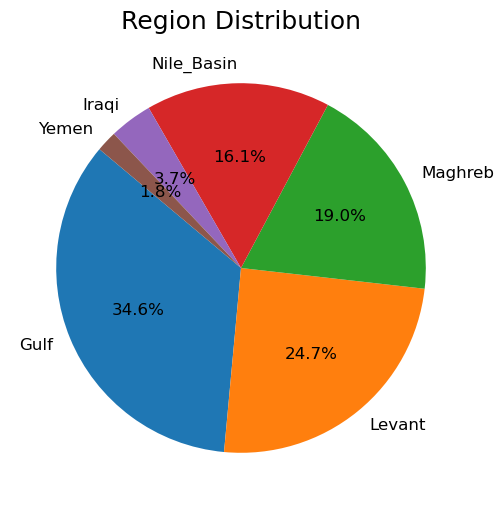

In [28]:
# رسم المخططات
plt.figure(figsize=(12, 6))  
# chart pie for region
plt.pie(region_texts, labels=region_texts.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
plt.title('Region Distribution', fontsize=18)
plt.show()  

<div dir="rtl">نلاحظ في المخطط السابق توزع النصوص على المناطق المختلفة ونلاحظ أن التوزع غير متوازن فمنطقة الخليج Gulf تحوي أكثر عدد من البيانات بينما تندر البيانات في منطقتي اليمن والعراق<div>

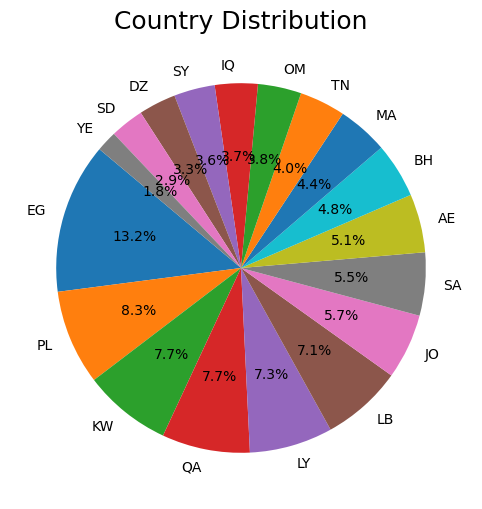

In [13]:
#chart pie for country
plt.figure(figsize=(12, 6))  
plt.pie(country_texts, labels=country_texts.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 10})
plt.title('Country Distribution', fontsize=18)
plt.show() 

<div dir="rtl"> نلاحظ من المخطط السابق أن التوزيع بين البلدان أيضاً غير متوازن فتملك مصر أكبر عدد من البيانات بينما تقل البيانات في اليمن والسودان مقارنة بالبقية <div>

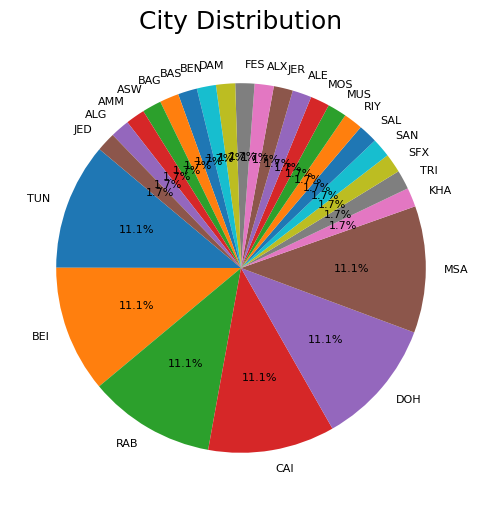

In [14]:
#chart pie for city
plt.figure(figsize=(12, 6)) 
plt.pie(city_texts, labels=city_texts.index, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
plt.title('City Distribution', fontsize=18)
plt.show() 

<div dir="rtl">بما أن التوزيع حسب المدينة مرتبط بمجموعة Madar فنلاحظ أن التوزيع متوازن بين 25 مدينة بنسبة 1.7% ومتوازن بين الخمس مدن الباقية والعربية الفصحى بنسبة أكبر وهي 11.1%  <div>
<div dir="rtl">وهذا بسبب أن مجموعة Madar هي عبارة عن مجموعتين واحدة نصوص مترجمة إلى لهجة 25 مدينة وللعربية الفصحى ومجموعة ثانية تحوي نصوص مترجمة إلى لهجة 5 مدن مختارة من ال25 مدينة بالاضافة إلى اللغة العربية الفصحى لذلك نرى زيادة بنسبة البيانات عند هذه المدن الخمسة وعند العربية الفصحى MSA<div>

## [2.2]

<div dir="rtl"> في الكود التالي يتم تقسيم النص باعتماد طريقة TweetTokenizer بسبب انها مخصصة لتعليقات السوشل ميديا فتتعامل بشكل جيد مع الروابط واسماء الحسابات والرموز التعبيرية<div>

In [53]:
def tokenize(text):
    text = re.sub('\n', ' ', text)
    tokenizer = TweetTokenizer(strip_handles=True)
    tokens = tokenizer.tokenize(text)
    
    return tokens



In [54]:
#تطبيق التابع على كل سطر وحفظ النتائج في عمود جديد في الداتا
final_train['tokenized_text']= final_train['text'].apply(tokenize)

In [10]:
print(final_train['tokenized_text'][:5])

0    [هو, هنيك, ،, قدام, معلومات, السياح, بالضبط, .]
1          [مالي, سمعان, من, قبل, بهالعنوان, هون, .]
2             [روح, ساوي, لبين, ما, تشوف, صيدلية, .]
3                                  [بشقد, الفطور, ؟]
4                            [شلون, بقدر, أساعدك, ؟]
Name: tokenized_text, dtype: object


In [30]:
# حساب عدد الكلمات الكلي 
total_tokens_count = final_train['tokenized_text'].apply(len).sum()
print(f"total_tokens_count: {total_tokens_count}")


total_tokens_count: 7333067


In [9]:
# دمج القوائم حيث كل قائمة تعبر عن كلمات سطر في مجموعة البيانات

#all_tokens= sum(total_tokens, [])
all_tokens = list(itertools.chain.from_iterable(final_train['tokenized_text']))
tokens_series = pd.Series(all_tokens)

In [32]:
# حساب تكرارات كل عنصر
value_counts  = tokens_series.value_counts()
# حساب عدد العناصر التي تظهر مرة واحدة فقط
unique_tokens_count = (value_counts == 1).sum()
print(f"vocab (unique_tokens_count): {unique_tokens_count}")

vocab (unique_tokens_count): 398166


## [2.3]

<div dir="rtl">في هذا القسم سنرسم الـ word cloud لكامل البيانات<div>

In [10]:
# جمع جميع التوكنز في نص واحد
text = " ".join(tokens_series)


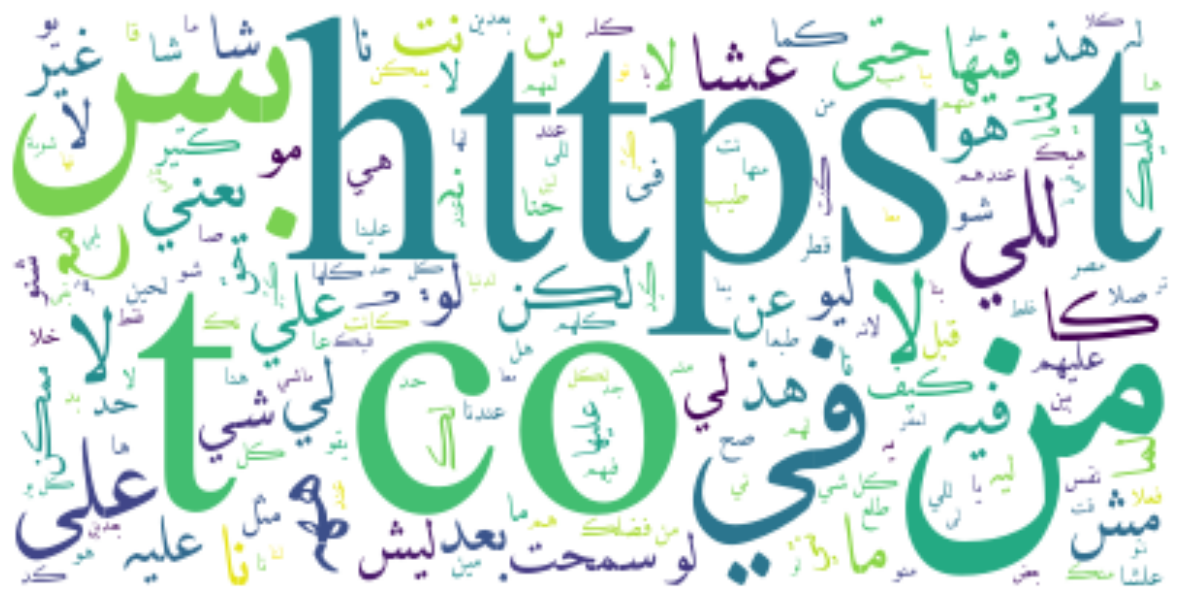

In [26]:
# إعادة تشكيل النص العربي ليعرض حروف الكلمة الواحدة بشكل متصل وليس منفصل
reshaped_text = arabic_reshaper.reshape(str(text))

# تطبيق الخوارزمية ثنائية الاتجاه لعرض النص من اليمين إلى اليسار
bidi_text = get_display(reshaped_text)

plt.figure(figsize=(15, 15))

wordcloud = WordCloud(
    font_path='MBKhursheed.ttf',  
    background_color='white'
).generate(bidi_text)


plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off") 
plt.show()

<div dir="rtl">من الرسم السابق نستنتج ان اكثر الكلمات تكراراً هي الـstopwords مثل: من و في وعلى بالإضافة إلى الروابط<div>
<div dir="rtl">يوجد أيضاً كلمات عامية مكررة يجب التفكير فيها لمعرفة إذا كنا سنعاملها معاملة الـstopwords مثلاً الكلمات: بس و اللي والضحك (هههه...)<div>
<div dir="rtl">لاحظنا أيضاً كلمات مكررة من الممكن ألا تفيد في مسألة مثل مسألة تحديد اللهجة مثل: أسماء البلدان مثل قطر و مصر <div>
<div dir="rtl">سيتم التفكير بهذه الحالات وغيرها للاستفادة منها في الطلبات القادمة<div>

## [2.4]

<div dir="rtl">في هذا الطلب مطلوب بناء تابع وتطبقه على البيانات كاملة وعلى المستويات الثلاثة:<div>
<div dir="rtl">أولاً لتطبيق التابع على المستويات الثلاثة جمعنا كل النصوص الخاصة بكل بلد في dictionary وكذلك كل النصوص الخاصة بكل مدينة وبكل منطقة<div>
<div dir="rtl">مثال عن الجمع كيف سيكون وهكذا من اجل بقية المدن والبلدان والمناطق<div>

   
```python
{
    'DAM': ['token1','token2','token3'......],
    'ALL': ['token1','token2','token3'......],
    'GZA': ['token1','token2','token3'......],
    ......
    ......
}

In [55]:
#تجميع الداتا حسب البلد
country_grouped = final_train.groupby('Country', dropna=True)
#جمع نصوص كل بلد بسلسلة   
flattened_country_texts = country_grouped['tokenized_text'].apply(lambda x: list(itertools.chain.from_iterable(x)))

In [56]:
#تجمع الداتا حسب المدينة
city_grouped=final_train.groupby('City', dropna=True)
#جمع نصوص كل مدينة بسلسلة
flattened_city_texts = city_grouped['tokenized_text'].apply(lambda x: list(itertools.chain.from_iterable(x)))

In [57]:
#تجمع الداتا حسب المنطقة
region_grouped=final_train.groupby('Region', dropna=True)
#جمع نصوص كل منطقة بسلسلة
flattened_region_texts = region_grouped['tokenized_text'].apply(lambda x: list(itertools.chain.from_iterable(x)))

In [22]:
#التابع المطلوب
def analyze_text(tokenized_text, n, name): #الدخل الثالث هو اسم البلد او المنطقة او المدينة من اجل طباعتها فقط
    # حساب الكلمات الاكثر تكرار
    most_common_words = Counter(tokenized_text)
    top_n_words = most_common_words.most_common(n)

    # حساب الكلمات الأقل تكرار
    least_common_words = most_common_words.most_common()[-n:]

    #حساب اكثر الثنائيات تكرار عن طريق تشكيل الثنائيات أولا ثم حساب تكراراتها واعادة اكثرها تكرار
    bigrams = ngrams(tokenized_text, 2)
    bigram_counts = Counter(bigrams)
    most_frequent_bigrams = bigram_counts.most_common(n)

    # حساب أكثر ثنائيات الكلمات أهمية باستخدام PMI
    finder = BigramCollocationFinder.from_words(tokenized_text)
    bigram_measures = BigramAssocMeasures()
    collocations_bigrams = finder.nbest(bigram_measures.pmi, n)

    # حساب أكثر ثلاثيات الكلمات تكرار
    trigrams = ngrams(tokenized_text, 3)
    trigram_counts = Counter(trigrams)
    most_frequent_trigrams = trigram_counts.most_common(n)

    # حساب أكثر ثلاثيات الكلمات أهمية باستخدام PMI
    finder = TrigramCollocationFinder.from_words(tokenized_text)
    trigram_measures = TrigramAssocMeasures()
    collocations_trigrams = finder.nbest(trigram_measures.pmi, n)

    
    print(f"\nTop {n} words in {name} are:")
    print(' // '.join([f" [{word}] " for word, freq in top_n_words]))

    print(f"\nLeast common {n} words (hapaxes) in {name} are:")
    print(' // '.join([f" [{word}] " for word, freq in least_common_words]))

    print(f"\nTop {n} most frequent bigrams in {name} are:")
    print(' // '.join([f" [{bigram[1]} ] [{bigram[0]}] " for bigram, freq in most_frequent_bigrams]))

    print(f"\nTop {n} most significant bigrams (collocations bigrams) in {name} are:")
    print(' // '.join([f" [{bigram[1]}] [{bigram[0]}] " for bigram in collocations_bigrams]))

    print(f"\nTop {n} most frequent trigrams in {name} are:")
    print(' // '.join([f" [{trigram[2]}] [{trigram[1]}] [{trigram[0]}] " for trigram, freq in most_frequent_trigrams]))

    print(f"\nTop {n} most significant trigrams (collocations trigrams) in {name} are:")
    print(' // '.join([f" [{trigram[2]}] [{trigram[1]}] [{trigram[0]}] " for trigram in collocations_trigrams]))

    print("_" * 150)


<div dir="rtl">تطبيق التابع على مستوى البلدان: <div>

In [43]:
for name, texts in flattened_country_texts.items():
    analyze_text(texts,10,name)


Top 10 words in AE are:
 [من]  //  [ما]  //  [..]  //  [في]  //  [و]  //  [.]  //  [😂]  //  [اللي]  //  [،]  //  [الله] 

Least common 10 words (hapaxes) in AE are:
 [https://t.co/Yc1zPtLBOK]  //  [هالشهص]  //  [يستكشف]  //  [ارجاء]  //  [https://t.co/jVQwnRBGbj]  //  [سراي]  //  [ماتييج]  //  [ماستخدم]  //  [تضربج]  //  [حكوكة] 

Top 10 most frequent bigrams in AE are:
 [😂 ] [😂]  //  [! ] [!]  //  [🤣 ] [🤣]  //  [️ ] [❤]  //  [، ] [،]  //  [الله ] [شاء]  //  [! ] [؟]  //  [؟ ] [؟]  //  [شاء ] [ان]  //  [❤ ] [️] 

Top 10 most significant bigrams (collocations bigrams) in AE are:
 [https://t.co/CP1tT0fC9r] [##R4ELive]  //  [https://t.co/Ifvw8TIpTM] [#10YearChallenge]  //  [https://t.co/xDBQkgaXES] [#10yearchallenge]  //  [#BBM_on_iOS_and_Android] [#BB4ALL]  //  [#BB4ALL] [#BBM]  //  [http://t.co/25J9aa4zjM] [#BBM_on_iOS_and_Android]  //  [https://t.co/LbglkaL8ET] [#Dubai]  //  [#العيد] [#Eid]  //  [https://t.co/TSmcJpBsm9] [#FIFA17]  //  [اتفو] [#GoodMorning] 

Top 10 most frequent trig

<div dir="rtl">تطبيق التابع على مستوى المدن:<div>

In [44]:
for name, texts in flattened_city_texts.items():
    analyze_text(texts,10,name)


Top 10 words in ALE are:
 [.]  //  [؟]  //  [،]  //  [إذا]  //  [سمحت]  //  [بدي]  //  [ما]  //  [من]  //  [خرج]  //  [رح] 

Least common 10 words (hapaxes) in ALE are:
 [هالجولة]  //  [زيارة]  //  [لبرج]  //  [سيرس]  //  [المدرسة]  //  [الصيفية]  //  [بجامعة]  //  [نمر]  //  [وطفل]  //  [بحمام] 

Top 10 most frequent bigrams in ALE are:
 [سمحت ] [إذا]  //  [إذا ] [،]  //  [. ] [سمحت]  //  [بدي ] [.]  //  [بدي ] [؟]  //  [خرج ] [.]  //  [إذا ] [.]  //  [رح ] [.]  //  [في ] [.]  //  [وين ] [.] 

Top 10 most significant bigrams (collocations bigrams) in ALE are:
 [تمانين] [آجارها]  //  [لبرا] [آخدن]  //  [موانا] [آلا]  //  [بقدم] [آمن]  //  [الموعد] [أأجل]  //  [لمجلس] [أبعتها]  //  [الركود] [أثر]  //  [بهالكيس] [أحطو]  //  [الشرطة] [أخبر]  //  [وحبار] [أخطبوط] 

Top 10 most frequent trigrams in ALE are:
 [سمحت] [إذا] [،]  //  [.] [سمحت] [إذا]  //  [سمحت] [إذا] [.]  //  [؟] [سمحت] [إذا]  //  [شي] [في] [.]  //  [سمحت] [إذا] [؟]  //  [،] [طيب] [؟]  //  [،] [نعم] [.]  //  [،] [أوه] [.]  //

<div dir="rtl">تطبيق التابع على مستوى المناطق:<div>

In [45]:
for name, texts in flattened_region_texts.items():
    analyze_text(texts,10,name)


Top 10 words in Gulf are:
 [من]  //  [😂]  //  [.]  //  [،]  //  [ما]  //  [في]  //  [..]  //  [!]  //  [اللي]  //  [؟] 

Least common 10 words (hapaxes) in Gulf are:
 [https://t.co/Aw94UREFzb]  //  [https://t.co/r94GhapKD1]  //  [والعرة]  //  [️دوم]  //  [تساوت]  //  [تضربج]  //  [حكوكة]  //  [بطيييء]  //  [ksa]  //  [هالدلوع] 

Top 10 most frequent bigrams in Gulf are:
 [😂 ] [😂]  //  [! ] [!]  //  [، ] [،]  //  [️ ] [❤]  //  [؟ ] [؟]  //  [🤣 ] [🤣]  //  [سمحت ] [لو]  //  [الله ] [شاء]  //  [! ] [؟]  //  [لو ] [،] 

Top 10 most significant bigrams (collocations bigrams) in Gulf are:
 [https://t.co/CP1tT0fC9r] [##R4ELive]  //  [https://t.co/Ylyp9kZGoe] [##امنيتك_بسنه_2018]  //  [نساافر] [##ماخفي_اعظم]  //  [https://t.co/se0aLQFnqQ] [##مزه]  //  [https://t.co/Ifvw8TIpTM] [#10YearChallenge]  //  [https://t.co/Qor4rvidwH] [#10yearchallange]  //  [#عاشت_البحرين] [#14_فبراير]  //  [https://t.co/x12yBQv7v0] [#32]  //  [https://t.co/1iFjhA3JlK] [#4مليون_قلب_حلم_واحد]  //  [http://t.co/jnR3z45Q

<div dir="rtl">تطبيق التابع على البيانات كاملة:<div>

In [48]:
analyze_text(all_tokens,10,"ALL_DATA")


Top 10 words in ALL_DATA are:
 [.]  //  [😂]  //  [من]  //  [؟]  //  [،]  //  [في]  //  [ما]  //  [و]  //  [..]  //  [اللي] 

Least common 10 words (hapaxes) in ALL_DATA are:
 [نغنيلها]  //  [بيضوّي]  //  [بفرزوا]  //  [تضربج]  //  [حكوكة]  //  [بسكنان]  //  [ويسرد]  //  [http://t.co/v4H8MfZ7mk]  //  [بطيييء]  //  [هالدلوع] 

Top 10 most frequent bigrams in ALL_DATA are:
 [😂 ] [😂]  //  [! ] [!]  //  [؟ ] [؟]  //  [، ] [،]  //  [️ ] [❤]  //  [🤣 ] [🤣]  //  [الله ] [شاء]  //  [! ] [؟]  //  [سمحت ] [لو]  //  [😍 ] [😍] 

Top 10 most significant bigrams (collocations bigrams) in ALL_DATA are:
 [https://t.co/CP1tT0fC9r] [##R4ELive]  //  [https://t.co/yntUES7XHH] [##السودان_موكب_18يناير]  //  [https://t.co/Ylyp9kZGoe] [##امنيتك_بسنه_2018]  //  [نساافر] [##ماخفي_اعظم]  //  [https://t.co/se0aLQFnqQ] [##مزه]  //  [#ندا_عادل_فين] [#100_يوم_على_اختفاء_ندا]  //  [https://t.co/hUsCUbyI9Y] [#10YearChallange]  //  [#10YearChallange] [#10yearchallege]  //  [https://t.co/4kNDhCKMjV] [#112_سنه_اهلى]  //  [

## [2.5]

<div dir="rtl">الكود التالي لايجاد الكلمات المميزة لكل بلد ولكل منطقة ولكل مدينة تم الاعتماد على سلاسل النصوص الخاصة بكل لهجة التي عملنا عليها في الطلب السابق أما طريقة إيجاد الكلمة المميزة فتم بالاعتماد على تكرارها في تلك اللهجة فوق عتبة معينة threshold=10 وتميزها في هذه اللهجة أي أنها غير موجودة ف كلمات اللهجات الأخرى<div>

In [51]:
from collections import Counter

def unique_dialect_words(flattened_data, threshold=10):
    dialect_words = {}
    
    for dialect, words in flattened_data.items():
        current_word_counts = Counter(words)
        
        other_words = [
            word
            for other_dialect, other_word_list in flattened_data.items()
            if other_dialect != dialect
            for word in other_word_list
        ]
        
        other_word_set = set(other_words)
        
        unique_words = [
            word
            for word, count in current_word_counts.items()
            if word not in other_word_set and count > threshold
        ]
        
        # نرتب الكلمات حسب عدد مرات ظهورها (تنازليًا)
        sorted_unique_words = sorted(unique_words, key=lambda x: current_word_counts[x], reverse=True)
        
        dialect_words[dialect] = sorted_unique_words
        
        print(f"unique words in {dialect}:")
        print(" || ".join(sorted_unique_words))
        print("_" * 150)
    
    return dialect_words

In [58]:
unique_country_words = unique_dialect_words(flattened_country_texts)

unique words in AE:
أبغا || #خزيميات || الشرجاوي || الشارجه || #R4ELive || اتريا || بليجريني || بيبييي || العيناويه || هاييل || المعلايه || بوشهاب || الوووصل || عيناويه || عيمان || #ipau || #الاجودي || والحينه || الشرجاوية || #منشن_شخص || فاندرلي || نيانجولان
______________________________________________________________________________________________________________________________________________________
unique words in BH:
#عبدالعزيز_الرويحي || #سمر_البحرينيه || #سمر_البحرينية || #waycoolshots || #Bahrain || #عادل_محمود || #uob || #غرد_بفتوى || #bahrain || #بونجاح_مطلب_اتحادي || اكريلك || بورترية || مـب || حميديتش || هونيس || انتون || cm || تويتش || #سكس || مَـــا || #نيك || آيران || #الرسام_البحرين || يَـــا || https://t.co/K0BQL0m9B7 || #سحاق || إلّلـي || عَـلـى || #photograpic_bh || #insta_souls_features || #تركي_اهبط_الاتحاد6 || وسلااامة || #pic_groups || #المحرق || #تركي_اهبط_الاتحاد20 || الجمري || عراد || #FotoBahrain || آآآمـيـن || السكلر || #تحديات_شيعية || #دياثة || البارك

In [78]:
unique_city_words = unique_dialect_words(flattened_city_texts)

unique words in ALE:
إيمت || هلئ || مشان
______________________________________________________________________________________________________________________________________________________
unique words in ALG:
تع || صحا || دوكا || لوكان
______________________________________________________________________________________________________________________________________________________
unique words in ALX:

______________________________________________________________________________________________________________________________________________________
unique words in AMM:
إشي
______________________________________________________________________________________________________________________________________________________
unique words in ASW:

______________________________________________________________________________________________________________________________________________________
unique words in BAG:
كولش || بلية || تكولي || رجائا
___________________________________

In [79]:
unique_region_words = unique_dialect_words(flattened_region_texts)

unique words in Gulf:
🇴🇲 || هذيلا || #عبدالعزيز_الرويحي || بوحمد || #المهدي_تركي || احين || 🏃🏼‍♂ || بوخالد || يديد || اليهال || چذي || #سمر_البحرينيه || #عبدالله_العصيدان || 🔷 || ألحين || اليديد || #ناطر_بيت || الحينه || #سمر_البحرينية || يهال || 5C292DCB || امحق || إعليميه || نوخذاك || #waycoolshots || 👦🏿 || ويهه || فنغر || الشبوك || اييب || عسب || #الغرافه || #السد || #ابيات || تكفه || صحار || يالس || اقولج || #Bahrain || ليلحين || #عوض_العلياني || الغرافه || خنور || بوراشد || تحاتي || كذاك || بالغزو || النعاشه || غرشة || يحتاي || يابوحمد || صباحج || بسنا || #عادل_محمود || الشرهة || الدريشة || الرياييل || جذيه || لاعدمتك || صلاله || الرياجيل || يالشيخ || واايد || ذيلا || تقدرين || ✽ || مايحتاي || الرويحي || عرباوي || تلايط || #ناصر_الحضرمي || يديده || استانست || يديدة || يدشون || اليديده || بوحمود || مطنزه || #انتر_ميلان || يبيلهم || ويهج || روحج || وربعنا || صلالة || يداومون || بوجاسم || لچ || وخله || بوفهد || #uob || #الجيش_السلماني || بالديره || شفيج || #غرد_بفتوى || شخبارك || عط 

<div dir="rtl">الملاحظات:<div>
<div dir="rtl">هناك اختلاف في أعداد الكلمات المميزة للهجات البلدان مثل في مصر والمغرب وتونس تأخذ العدد الاكبر وهذا لان لهجة مثل لهجة مصر مميزة أي لا تتكرر كلماتها بغير بلدان وكذلك الأمر بالنسبة لبلاد المغرب بينما من الممكن أن تتشابه لهجات بلدان ثانية فلا ينتج العديد من الكلمات المميزة لهذا البلد مثل الأردن لم ينتج الكثير من الكلمات المميزة وهذا ممكن أن يكون بسبب تشابه لهجة الأردن مع بلدان ثانية كفلسطين مثلاً<div>
<div dir="rtl">نلاحظ أيضاً في البلدان ظهور هاشتاغات وروابط وهذا لأن الداتا مأخوذة من تويتر وغير منظفة فيؤثر وجود هاشتاغات مكررة في تعليقات البلد على نتائج التابع أي يظهر الهاشتاغ أو الرابط ككلمة مميزة لهذا البلد<div>
<div dir="rtl">نفس الشيء بالنسبة للمدن لكن نلاحظ أن هناك مدن لم يظهر لها أي كلمات مميزة مثل السلط في الاردن والاسكندرية واسوان في مصر وهذا أيضاً ممكن أن ينتج بسبب تشابه لهجات المدن في البلد الواحد مثلا الاسكندرية واسوان ممكن انهم متشابهان مع القاهرة ونفس الشيء بالنسبة للسلط يبدو أن لهجتها غير مميزة من الممكن ان تكون متشابهة مع لهجة عمان او لهجة مدن فلسطينية<div>

## [2.6]

<div dir="rtl">في الطلب التالي أيضاً سوف نستخدم البيانات المحضرة مسبقاً (نصوص كل بلد وكل مدينة وكل منطقة) وسنستخدم ثلاث توابع أولاً لحساب مصفوفة التشابه ثم لعرض المخططات<div>
<div dir="rtl">الهدف من التابع هو قياس التشابه بين كل زوج من اللهجات بناءً على الكلمات المشتركة <div>
<div dir="rtl">تم حساب نسبة التشابه بين كل زوج من اللهجات باستخدام Jaccard Similarity:  |A∩B|/|A∪B|  وهو يحسب النسبة بين عدد الكلمات المشتركة بين اللهجتين (التقاطع) على عدد الكلمات الفريدة في كل من اللهجتين (الاجتماع)<div>

In [33]:
def compute_similarity_matrix(flattened_data):
    # تحويل قوائم الكلمات إلى مجموعات (sets)
    grouped_data = flattened_data.apply(lambda x: set(x))
    
    # إنشاء مصفوفة التشابه بحيث تكون الصفوف والاعمدة هي اسماء اللهجات
    dialects = grouped_data.index
    similarity_matrix = pd.DataFrame(index=dialects, columns=dialects, dtype=float)

    #حساب التشابه بين كل زوج لهجات
    for d1, d2 in combinations(dialects, 2): #ترجع جميع الازواج (2) الممكنة من اسماء اللهجات
        words1, words2 = grouped_data[d1], grouped_data[d2]
        similarity = len(words1.intersection(words2)) / len(words1.union(words2))
        similarity_matrix.at[d1, d2] = similarity
        similarity_matrix.at[d2, d1] = similarity

    #  يتم تعبئة القطر الرئيسي للمصفوفة بـ 1.0 لأن التشابه بين اللهجة ونفسها هو 1 
    similarity_matrix.fillna(1.0, inplace=True)
    return similarity_matrix


def show_heatmap(similarity_matrix):    
    plt.figure(figsize=(12, 10))
    sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.tight_layout()
    plt.title('Heatmap for Dialect Similarity', fontsize=16)
    plt.show()


def show_linkage_Hierarchical(similarity_matrix):
    #تحويل مصفوفة التشابه إلى مصفوفة مسافات لان المخطط يعتمد على المسافات وليس نسب تشابه 
    condensed_distance = squareform(1 - similarity_matrix)
    # انشاء مصفوفة التجميع الهرمي (سنجمع اللهجات المتشابهة في مجموعات من خلالها)
    linkage_matrix = linkage(condensed_distance)
    
    plt.figure(figsize=(12, 8))
    dendrogram(linkage_matrix, labels=similarity_matrix.index, leaf_rotation=90)
    plt.title('Hierarchical Clustering of Dialects')
    plt.xlabel('Dialects')
    plt.ylabel('Distance')
    plt.show()

In [36]:
similarity_matrix_country = compute_similarity_matrix(flattened_country_texts)
similarity_matrix_city = compute_similarity_matrix(flattened_city_texts)
similarity_matrix_region = compute_similarity_matrix(flattened_region_texts)

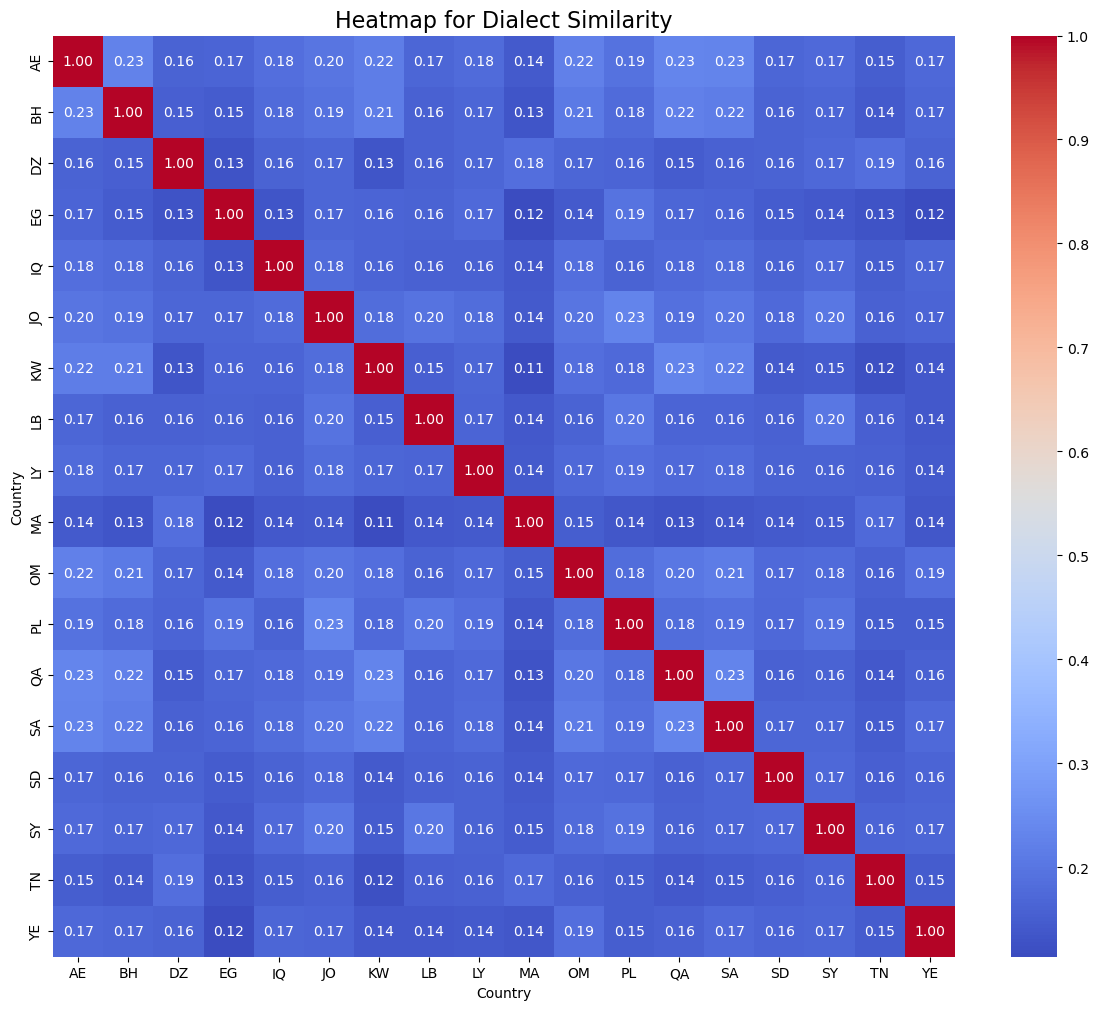

In [37]:
show_heatmap(similarity_matrix_country)

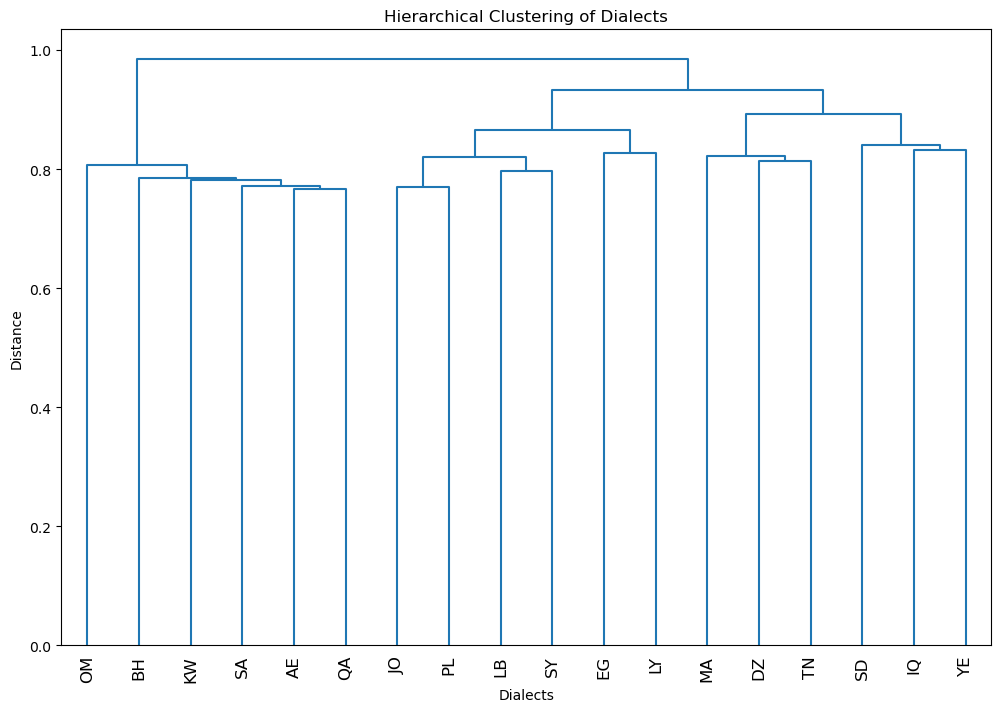

In [38]:
show_linkage_Hierarchical(similarity_matrix_country)

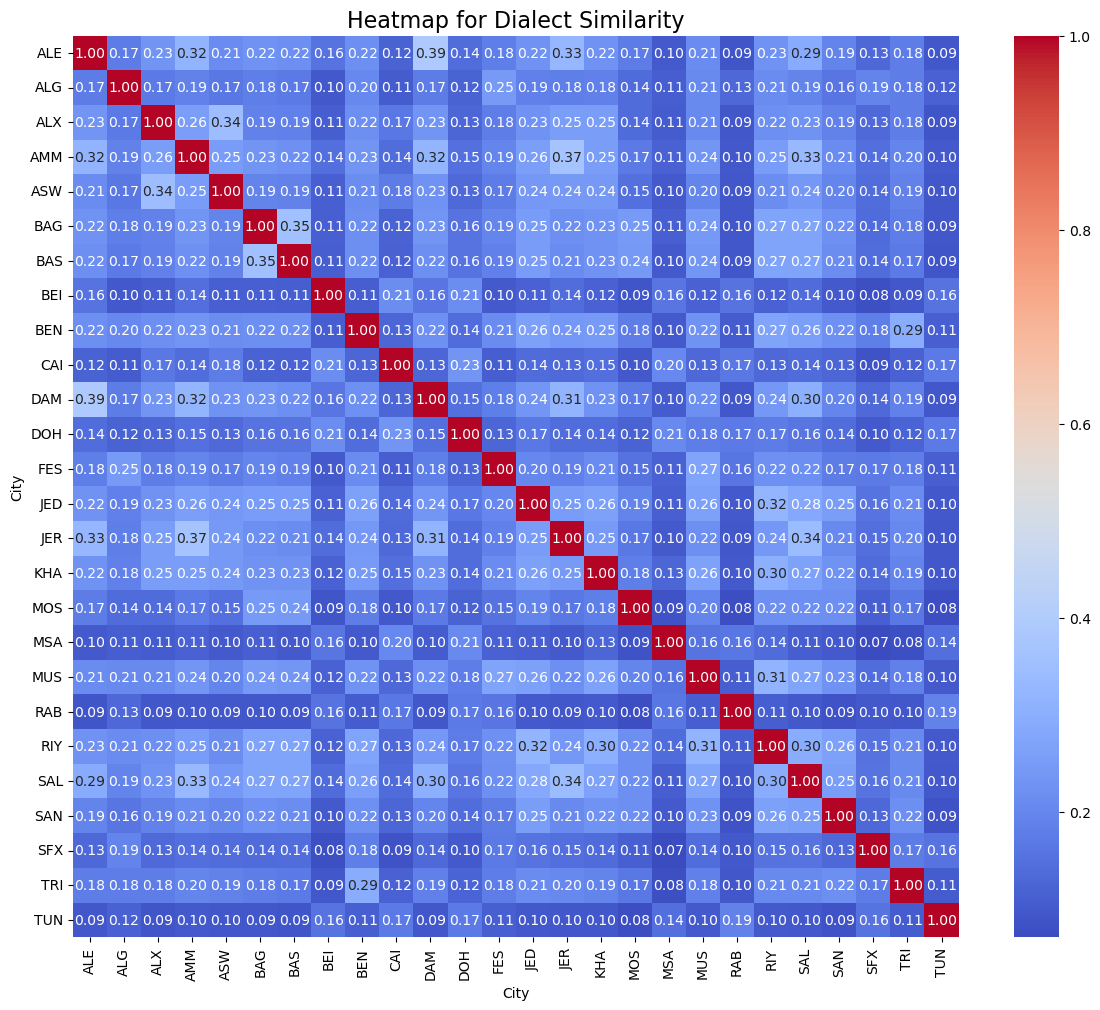

In [39]:
show_heatmap(similarity_matrix_city)

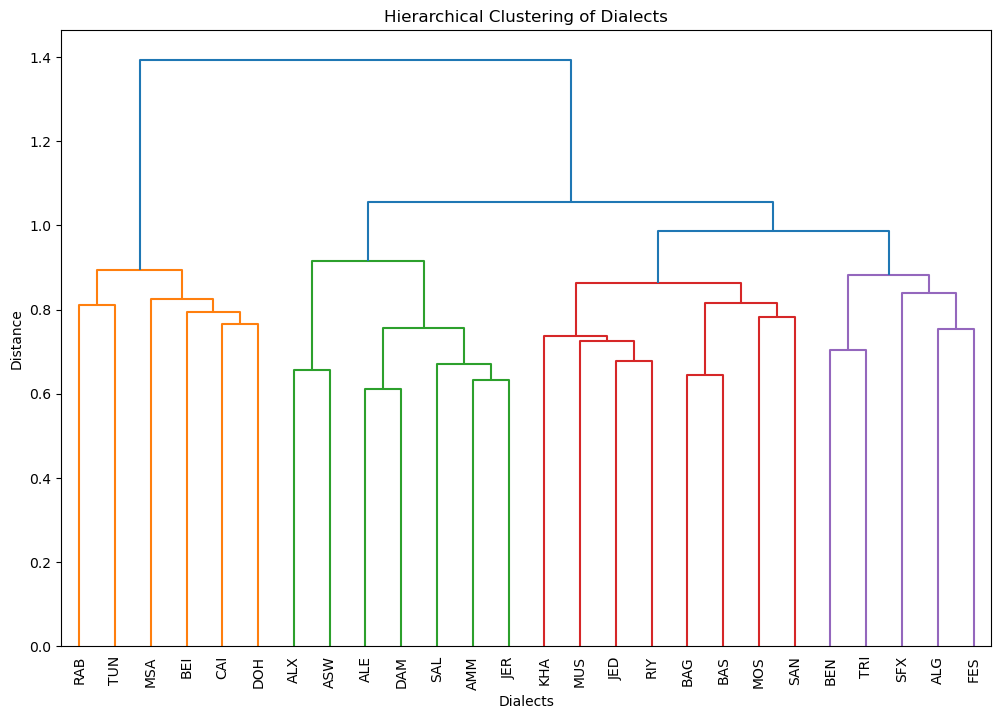

In [40]:
show_linkage_Hierarchical(similarity_matrix_city)

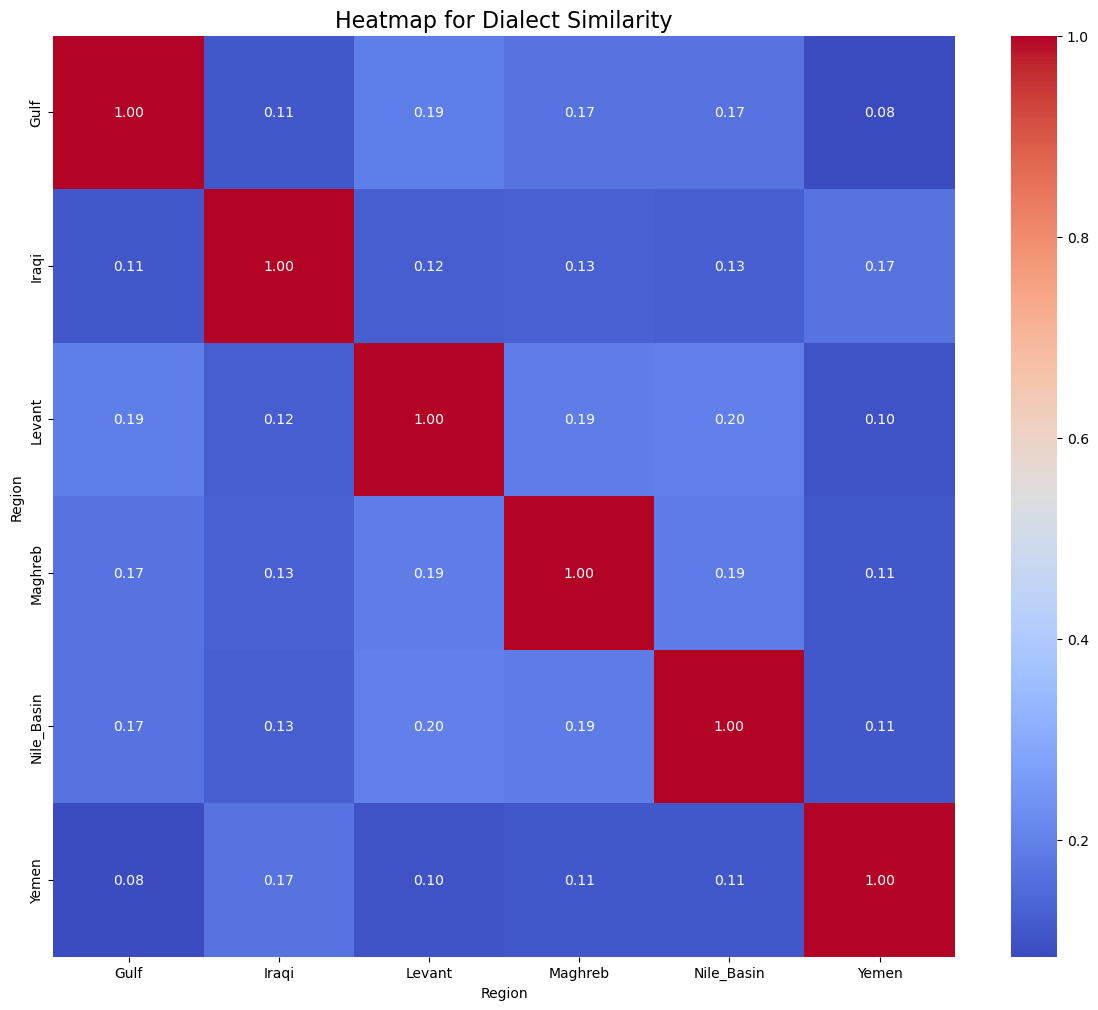

In [41]:
show_heatmap(similarity_matrix_region)

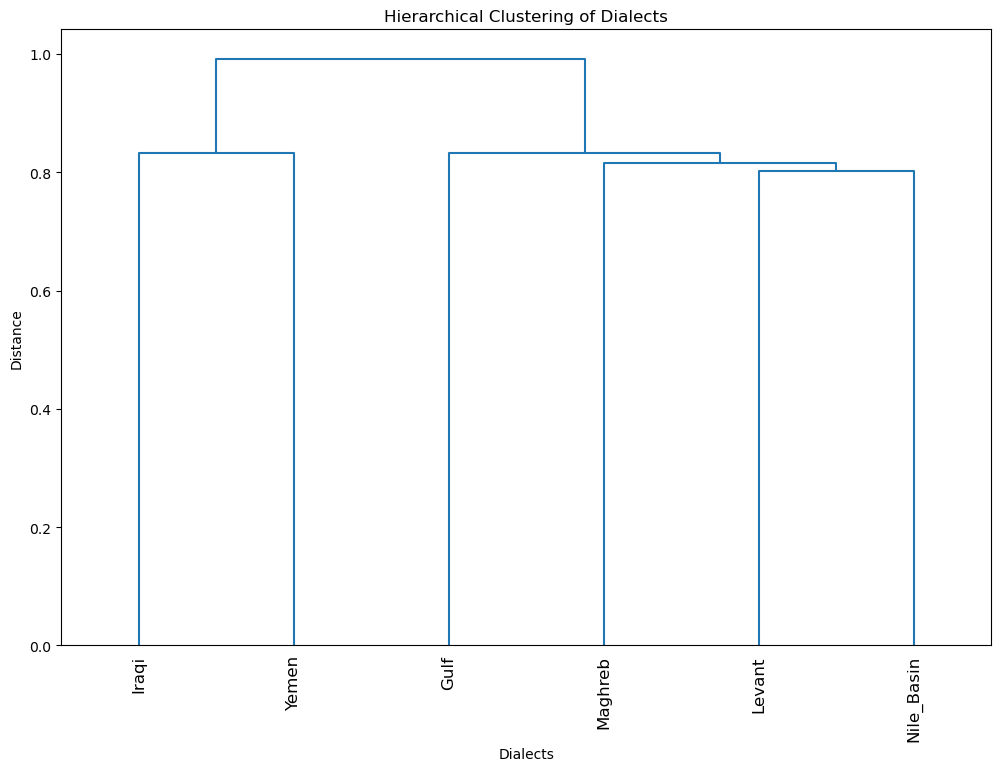

In [42]:
show_linkage_Hierarchical(similarity_matrix_region)

<div dir="rtl">ملاحظات:<div>
<div dir="rtl">تدعم المخططات الحالات التي لاحظناها في الطلب السابق لنأخذ مثال من البلدان: الامارات لم يظهر فيها الكثير من الكلمات المميزة في الطلب السابق واذا نظرنا للـ heat map نرى انها تملك نسب تشابه عالية مع بقية بلدان الخلج مثل السعودية وقطر بينما بلد مثل مصر التي ظهرت فيها العديد من الكلمات المميزة تكون نسب التشابه مع بقية البلدان قليلة او متوسطة واذا نظرنا لمخطط المجموعات نرى أيضاً ان بلد مثل الامارات تم جمعها في مجموعات اكثر من مصر<div>
<div dir="rtl">لنأخذ مثال من المدن مدينة السلط التي لم يظهر لها كلمات مميزة في الطلب السابق نرى في المخططات انها تتشابه بنسب عالية مع العديد من المدن في بلدها وخارج بلدها مثلاً نسب تشابهها عالية مع حلب ودمشق وعمان والقدس وهذا ما يفسر عدم ظهور كلمات مميزة منها<div>

## [2.7]

In [16]:
def calculate_oov_ratio(model, tokenized_texts):
    
    oov_count = 0
    total_words = 0

    for tokens in tokenized_texts:
        for word in tokens:  
            total_words += 1
            if word not in model:
                oov_count += 1

    oov_ratio = oov_count / total_words 

    return oov_ratio

In [7]:
#fasttext
fasttext_model = KeyedVectors.load_word2vec_format('cc.ar.300.vec', binary=False)

In [18]:
fasttext_oov_ratio = calculate_oov_ratio(fasttext_model, final_train['tokenized_text'])
print(f"FastText oov ratio: {fasttext_oov_ratio:.2%}")

FastText oov ratio: 10.15%


In [ ]:
#word2vec
word2vec_model= Word2Vec.load('word2vec/tweets_cbow_300')

In [25]:
oov_count = 0
total_words = 0

for tokens in final_train['tokenized_text']:
    for word in tokens:  
        total_words += 1
        if word not in word2vec_model.wv:  
            oov_count += 1

# حساب نسبة OOV
word2vec_oov_ratio = oov_count / total_words

print(f"Word2Vec oov ratio: {word2vec_oov_ratio:.2%}")

Word2Vec oov ratio: 24.32%


In [27]:
#glove
glove_model=KeyedVectors.load_word2vec_format('vectors.txt', binary=False, no_header=True)

In [28]:
glove_oov_ratio = calculate_oov_ratio(glove_model, final_train['tokenized_text'])
print(f"GloVe oov ratio: {glove_oov_ratio:.2%}")

GloVe oov ratio: 22.28%


<div dir="rtl">نلاحظ ان النموذج fasttext يملك النسبة الأقل وهي 10.15%<div>

# مهمة 03 : تنظيف وتوحيد النص

normalization and cleaning Text

## [3.1]


<div dir="rtl">سنكتب تابع تنظيف واحد في كل خلية ونختبره على اول واخر 5 عينات تدريب وذلك للتحقق من فائدته على عينات مختلفة <div>

In [29]:
#stopwords
#سنزيلها لانها متكررة وغير مفيدة في مسألتنا

#nltk.download("stopwords") 

def delete_stop_words(text):
    
    stop_words = set(nltk.corpus.stopwords.words("arabic"))
    #اضفنا كلمات نظن انها غير مفيدة في مسألة تصنيف اللهجة وهي مكررة بكل اللهجات
    custom_stopwords = {"شاء", "الله" , "ماشالله", "انشاءالله", "انشالله" }  
    stop_words.update(custom_stopwords)
    return ' '.join(word for word in text.split() if word not in stop_words and len(word)>1)



In [15]:
# عرض النتائج
print(final_train['text'].head(5).apply(delete_stop_words))
print(final_train['text'].tail(5).apply(delete_stop_words))

0    هنيك، قدام معلومات السياح بالضبط.
1            مالي سمعان بهالعنوان هون.
2           روح ساوي لبين تشوف صيدلية.
3                         بشقد الفطور؟
4                    شلون بقدر أساعدك؟
Name: text, dtype: object
535647    انت مش مجبور تجامل حدا وتعطيه اكبر حجمه عادي ا...
535648    رتم الفريق بدون جيرو سريييييييييع جيرو يصير بط...
535649        🇸🇦💚🇸🇦💚🇸🇦 ksa 👆🏻 وغير هالبلد قلبي عشق يعشق 💚🇸🇦
535650    @a7lawa7di @ranim2298 خلص هيييك بطلت ادعي وأعط...
535651    @aalsubaie___ @Ahmedhalyami90 خيولي هالدلوع مر...
Name: text, dtype: object


In [8]:
#تابع التوحيد لإرجاع جميع الحرف إلى وضعها الطبيعي لانها لا تؤثر على المعنى ولا تزيد أي معلومة في مسألتنا
def normalize_arabic(text): 
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    text = re.sub("ڤ", "ف", text)
    text = re.sub("چ", "ج", text)
    text = re.sub("پ", "ب", text)
    text = re.sub("ڜ", "ش", text)
    text = re.sub("ڪ", "ك", text)
    text = re.sub("ٱ", "ا", text)
    #إزالة الحركات
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    # ازالة تطويل الحروف مثل بـــسم الله تعاد إلى بسم أو الــقمر تعاد إلى القمر
    text = re.sub(r'\u0640', '', text)
    #ازالة تكرار الحروف مثل مرحباااااا
    text = re.sub(r'(.)\1+', r'\1\1', text)
    # ازالة المسافات الاضافية
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text



In [17]:
# عرض النتائج
print(final_train['text'].head(5).apply(normalize_arabic))
print(final_train['text'].tail(5).apply(normalize_arabic))

0    هو هنيك، قدام معلومات السياح بالضبط.
1        مالي سمعان من قبل بهالعنوان هون.
2           روح ساوي لبين ما تشوف صيدليه.
3                            بشقد الفطور؟
4                       شلون بقدر اساعدك؟
Name: text, dtype: object
535647    انت مش مجبور تجامل حدا وتعطيه اكبر من حجمه ؛ ع...
535648    رتم الفريق بدون جيرو سرييع ، مع جيرو يصير بطيي...
535649    🇸🇦💚🇸🇦💚🇸🇦 ksa 👆🏻 وغير هالبلد قلبي ما عشق ولا را...
535650    @a7lawa7di @ranim2298 خلص اذا هييك بطلت ادعي و...
535651    @aalsubaie__ @Ahmedhalyami90 خيولي هالدلوع مره...
Name: text, dtype: object


In [9]:
#تنظيف النص من كل ما تبقى ولا يعبر عن كلمات عربية مثل علامات الترقيم والارقام والرموز التعبيرية والروابط 

def clean_tweets(text):
    
    #إزالة الرموز التعبيرية (الايموجي)
    text=emoji.replace_emoji(text, ' ')

    # إزالة الروابط (http و www)
    text = re.sub(r'http\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'www\S+', '', text, flags=re.MULTILINE)
    
    #ازالة علامات الترقيم والارقام العربية )
    punc = '''٠١٢٣٤٥٦٧٨٩۰۱۲۳۴۵۶۷۸۹،؛~؟-!()[]{};\,<>./?@#$%^&*~�_:'''
    for p in punc:
        text=text.replace(p, ' ')
    
    # إزالة كلمة "RT"
    text = text.replace('RT', '')
    
    # إزالة المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()
    
    
    return text





In [19]:
# عرض النتائج
print(final_train['text'].head(5).apply(remove_non_arabic_text))
print(final_train['text'].tail(5).apply(remove_non_arabic_text))

0    هو هنيك قدام معلومات السياح بالضبط
1       مالي سمعان من قبل بهالعنوان هون
2          روح ساوي لبين ما تشوف صيدلية
3                           بشقد الفطور
4                      شلون بقدر أساعدك
Name: text, dtype: object
535647    انت مش مجبور تجامل حدا وتعطيه اكبر من حجمه عاد...
535648    رتم الفريق بدون جيرو سريييييييييع مع جيرو يصير...
535649                 وغير هالبلد قلبي ما عشق ولا راح يعشق
535650                 خلص اذا هيييك بطلت ادعي وأعطي بركاتي
535651    خيولي هالدلوع مره زين عشره زفت يذلف باللي مايح...
Name: text, dtype: object


## [3.2]

In [10]:
#تعريف التابع العام الذي سينفذ التوابع السابقة على بيانات التدريب
def apply_cleaning_functions(text, functions_list):
    for func in functions_list:
        text = func(text)  
    return text

## [3.3]

In [33]:
#تطبيق التابع على بيانات التدريب كاملة 
cleaning_functions = [delete_stop_words, normalize_arabic, clean_tweets]

final_train['cleaned_text'] = final_train['text'].apply(lambda x: apply_cleaning_functions(x, cleaning_functions))


In [34]:
final_train['tokenized_cleaned_text']=final_train['cleaned_text'].apply(tokenize)

In [30]:
#حساب عدد البيانات الكلي والفريد بعد التنظيف
total_tokens_count = final_train['tokenized_cleaned_text'].apply(len).sum()
print(f"total_tokens_count: {total_tokens_count}")

all_tokens = list(itertools.chain.from_iterable(final_train['tokenized_cleaned_text']))
tokens_series = pd.Series(all_tokens)
value_counts  = tokens_series.value_counts()
# حساب عدد العناصر التي تظهر مرة واحدة فقط
unique_tokens_count = (value_counts == 1).sum()
print(f"vocab (unique_tokens_count): {unique_tokens_count}")

total_tokens_count: 5269140
vocab (unique_tokens_count): 241193


<div dir="rtl">عدد البيانات قبل التنظيف كان: 7333067 أصبح بعد اتنظيف: 5269140<div>
<div dir="rtl">عدد الكلمات الفريدة قبل التنظيف كان: 398166 وأصبح بعد التنظيف: 241193<div>

## [3.4]

<div dir="rtl">في هذا الكود سوف نتحقق من الاسطر الفارغة nan او الاسطر التي حذفت كل كلماتها اي انها تحوي سلسلة فارغة او الاسطر التي تحوي سلسلة مكونة من اقل من خمس محارف<div>
<div dir="rtl">استخدمنا .str.strip() == '' لنرى ان كان هناك سطر فيه مسافات فقط وتستخدم strip لحذف المسافات الاضافية لان اذا كانت غير موجودة لا يأخذ إلا النص الذي فيه مسافة واحدة<div>

In [35]:
empty_or_short_rows = final_train[
    final_train['cleaned_text'].isna() |  
    (final_train['cleaned_text'].str.strip() == '') |  
    (final_train['cleaned_text'].str.len() < 5)  
]
num_empty_or_short_rows = len(empty_or_short_rows)
print(f"عدد الأسطر الفارغة أو التي تحتوي على أقل من 5 محارف: {num_empty_or_short_rows}")

#حذف الاسطر
final_train.drop(empty_or_short_rows.index, inplace=True)

عدد الأسطر الفارغة أو التي تحتوي على أقل من 5 محارف: 1292


In [52]:
final_train.head()

,id,City,text,Region,Country,tokenized_text,cleaned_text,tokenized_cleaned_text
0,5,ALE,هو هنيك، قدام معلومات السياح بالضبط.,Levant,SY,"[هو, هنيك, ،, قدام, معلومات, السياح, بالضبط, .]",هنيك قدام معلومات السياح بالضبط,"[هنيك, قدام, معلومات, السياح, بالضبط]"
1,9,ALE,مالي سمعان من قبل بهالعنوان هون.,Levant,SY,"[مالي, سمعان, من, قبل, بهالعنوان, هون, .]",مالي سمعان بهالعنوان هون,"[مالي, سمعان, بهالعنوان, هون]"
2,11,ALE,روح ساوي لبين ما تشوف صيدلية.,Levant,SY,"[روح, ساوي, لبين, ما, تشوف, صيدلية, .]",روح ساوي لبين تشوف صيدليه,"[روح, ساوي, لبين, تشوف, صيدليه]"
3,26,ALE,بشقد الفطور؟,Levant,SY,"[بشقد, الفطور, ؟]",بشقد الفطور,"[بشقد, الفطور]"
4,27,ALE,شلون بقدر أساعدك؟,Levant,SY,"[شلون, بقدر, أساعدك, ؟]",شلون بقدر اساعدك,"[شلون, بقدر, اساعدك]"


# مهمة 04  : بناء النموذج المرجعي

Model Baseline

## [4.1]


In [36]:
X_train = final_train['text']
y_train = final_train[['City', 'Country', 'Region']]

X_test = final_test['text']
y_test = final_test[['City', 'Country', 'Region']]

X_validation=final_validation['text']
y_validation=final_validation[['City', 'Country', 'Region']]

## [4.2]

In [37]:
# تمثيل البيانات باستخدام tfidf
vectorizer = TfidfVectorizer(max_features=10000)  
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)



In [38]:
# تعبئة القيم المفقودة بقيمة "Unknown"
y_train = y_train.fillna("Unknown")
y_test = y_test.fillna("Unknown")
y_validation=y_validation.fillna("Unknown")

In [39]:
model = MultiOutputClassifier(MultinomialNB(alpha=0.1)) 
model.fit(X_train_tfidf, y_train)

MultiOutputClassifier(estimator=MultinomialNB(alpha=0.1))

## [4.3]

In [11]:
#تعريف جدول تخزين النتائج
comparison_table = {}
comparison_table['question_step_number'] = []
comparison_table['model_name'] = []
comparison_table['features'] = []
comparison_table['model_parameters'] = []
comparison_table['preprocessing_methods'] = []
comparison_table['target'] = []
comparison_table['accuracy'] = []
comparison_table['balance_accuracy'] = []
comparison_table['f1_score']= []

In [41]:
#تعريف دالة لاختبار نموذج وطباعة نتائجه
def evaluate_model(model, X_test, y_test, comparison_table, question_step_number, model_name, features, model_parameters, preprocessing_methods):

    y_predict = model.predict(X_test)
    
    # حساب المقاييس لكل فئة على حدة
    results = {}
    for i, col in enumerate(y_test.columns):
        accuracy = accuracy_score(y_test[col], y_predict[:, i])
        balance_accuracy = balanced_accuracy_score(y_test[col], y_predict[:, i])
        f1 = f1_score(y_test[col], y_predict[:, i], average='weighted')  
        results[col] = {
            'accuracy': accuracy,
            'balance_accuracy': balance_accuracy,
            'f1_score': f1
        }
    
    # إضافة النتائج إلى جدول المقارنة
    for col, names in results.items():
        comparison_table['question_step_number'].append(question_step_number)
        comparison_table['model_name'].append(model_name)
        comparison_table['features'].append(features)
        comparison_table['model_parameters'].append(model_parameters)
        comparison_table['preprocessing_methods'].append(preprocessing_methods)
        comparison_table['target'].append(col)  
        comparison_table['accuracy'].append(names['accuracy'])
        comparison_table['balance_accuracy'].append(names['balance_accuracy'])
        comparison_table['f1_score'].append(names['f1_score'])
    
    return comparison_table


comparison_table = evaluate_model(
    model=model, 
    X_test=X_test_tfidf,  
    y_test=y_test,  
    comparison_table=comparison_table,  
    question_step_number="4.3",  
    model_name='MultinomialNB',  
    features='TF-IDF',  
    model_parameters='alpha=0.1',  
    preprocessing_methods="None"  
)

pd.DataFrame(comparison_table).head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,4.3,MultinomialNB,TF-IDF,alpha=0.1,None,City,0.712432,0.248255,0.639721
1,4.3,MultinomialNB,TF-IDF,alpha=0.1,None,Country,0.496650,0.457028,0.478109
2,4.3,MultinomialNB,TF-IDF,alpha=0.1,None,Region,0.712996,0.578974,0.705062


## [4.4]

In [42]:
#تعريف دالة للتدريب باستخدام عملية تنظيف واحدة
def train_with_cleaning(X_train, X_test, y_train, y_test, comparison_table, question_step_number, model_name, features, model_parameters, preprocessing_methods, cleaning_function):
    # تطبيق دالة التنظيف على نصوص التدريب والاختبار
    X_train_cleaned = X_train.apply(cleaning_function)
    X_test_cleaned = X_test.apply(cleaning_function)
    
    #tfidf
    vectorizer = TfidfVectorizer(max_features=10000)
    X_train_tfidf = vectorizer.fit_transform(X_train_cleaned)
    X_test_tfidf = vectorizer.transform(X_test_cleaned)
    
    # تدريب النموذج
    model = MultiOutputClassifier(MultinomialNB(alpha=0.1))
    model.fit(X_train_tfidf, y_train)
    
    # تقييم النموذج وتخزين النتائج
    comparison_table = evaluate_model(
        model=model, 
        X_test=X_test_tfidf,  
        y_test=y_test,  
        comparison_table=comparison_table,  
        question_step_number=question_step_number,  
        model_name=model_name,  
        features=features,  
        model_parameters=model_parameters,  
        preprocessing_methods=preprocessing_methods
    )
    
    return comparison_table


In [43]:
#delete_stop_words
comparison_table = train_with_cleaning(
    X_train=X_train,  
    X_test=X_test,    
    y_train=y_train,  
    y_test=y_test,    
    comparison_table=comparison_table,  
    question_step_number="4.4",  
    model_name='MultinomialNB',  
    features='TF-IDF',  
    model_parameters='alpha=0.1',  
    preprocessing_methods="delete_stop_words",  
    cleaning_function=delete_stop_words  
)
df=pd.DataFrame(comparison_table)
filtered_df = df[df['preprocessing_methods'] == "delete_stop_words"]
filtered_df.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
3,4.4,MultinomialNB,TF-IDF,alpha=0.1,delete_stop_words,City,0.706086,0.232131,0.631484
4,4.4,MultinomialNB,TF-IDF,alpha=0.1,delete_stop_words,Country,0.481701,0.438533,0.462243
5,4.4,MultinomialNB,TF-IDF,alpha=0.1,delete_stop_words,Region,0.704252,0.554295,0.696442


<div dir="rtl">نلاحظ ان عملية التنظيف بحذف الـ Stopwords لم تزيد من الدقة والـ f_score<div>

In [44]:
#normalize_arabic
comparison_table = train_with_cleaning(
    X_train=X_train,  
    X_test=X_test,    
    y_train=y_train,  
    y_test=y_test,    
    comparison_table=comparison_table,  
    question_step_number="4.4",  
    model_name='MultinomialNB',  
    features='TF-IDF',  
    model_parameters='alpha=0.1',  
    preprocessing_methods="normalize_arabic",  
    cleaning_function=normalize_arabic  
)
df=pd.DataFrame(comparison_table)
filtered_df = df[df['preprocessing_methods'] == "normalize_arabic"]
filtered_df.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
6,4.4,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic,City,0.705028,0.229173,0.627232
7,4.4,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic,Country,0.493195,0.450921,0.473473
8,4.4,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic,Region,0.713842,0.576394,0.706629


<div dir="rtl">نلاحظ ان عملية توحيد شكل النصوص العربية زادت الدقة والـ f_score بالنسبة للمنطقة<div>

In [45]:
#clean_tweets
comparison_table = train_with_cleaning(
    X_train=X_train,  
    X_test=X_test,    
    y_train=y_train,  
    y_test=y_test,    
    comparison_table=comparison_table,  
    question_step_number="4.4",  
    model_name='MultinomialNB',  
    features='TF-IDF',  
    model_parameters='alpha=0.1',  
    preprocessing_methods="clean_tweets",  
    cleaning_function=clean_tweets  
)


In [46]:
df=pd.DataFrame(comparison_table)
filtered_df = df[df['preprocessing_methods'] == "clean_tweets"]
filtered_df.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
9,4.4,MultinomialNB,TF-IDF,alpha=0.1,clean_tweets,City,0.711797,0.246588,0.638581
10,4.4,MultinomialNB,TF-IDF,alpha=0.1,clean_tweets,Country,0.502503,0.461905,0.484931
11,4.4,MultinomialNB,TF-IDF,alpha=0.1,clean_tweets,Region,0.715253,0.581149,0.707265


<div dir="rtl">نلاحظ ان عملية تنظيف التغريدات زادت الدقة والـ f_score بشكل ملحوظ لكل من البلد والمنطقة<div>

## [4.5]

In [47]:
#normalize_arabic&&clean_tweets
X_train_normalized = X_train.apply(normalize_arabic)
X_test_normalized = X_test.apply(normalize_arabic)

X_train_cleaned = X_train_normalized.apply(clean_tweets)
X_test_cleaned = X_test_normalized.apply(clean_tweets)

X_train_tfidf = vectorizer.fit_transform(X_train_cleaned)
X_test_tfidf = vectorizer.transform(X_test_cleaned)

model = MultiOutputClassifier(MultinomialNB(alpha=0.1))
model.fit(X_train_tfidf, y_train)

comparison_table = evaluate_model(
    model=model, 
    X_test=X_test_tfidf,  
    y_test=y_test,  
    comparison_table=comparison_table,  
    question_step_number="4.5",  
    model_name='MultinomialNB',  
    features='TF-IDF',  
    model_parameters='alpha=0.1',  
    preprocessing_methods="normalize_arabic&&clean_tweets"  
)
df=pd.DataFrame(comparison_table)
filtered_df = df[df['preprocessing_methods'] == "normalize_arabic&&clean_tweets"]
filtered_df.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
12,4.5,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic&&clean_tweets,City,0.705521,0.230107,0.628233
13,4.5,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic&&clean_tweets,Country,0.499824,0.457372,0.481440
14,4.5,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic&&clean_tweets,Region,0.718285,0.579187,0.710740


## [4.6]

<div dir="rtl">في الكود التالي المطلوب ضبط المعاملات الـ tfidf vectorizer جربنا أولاً التالي:<div>
<div dir="rtl">1) زدنا عدد الـ max_features من الـ 10000 إلى الـ 20000 وأضفنا ngram_range=(1, 2) فنتج زيادة في الدقة<div>
<div dir="rtl">حيث في الـ max_features نحدد عدد اهم المصطلحات او الكلمات التي سيختارها الموذج و ngram_range=(1, 2) حددنا ان النموذج سيتضمن كلمات فردية وثنائيات كلمات bigrams وهذا وهذا سيساعد النموذج بملاحظة السياق والعلاقات بين الكلمات <div>
<div dir="rtl">2) اضفنا للمعاملات السابقة sublinear_tf=True وهي تطبق تحويل لوغاريتمي لتكرارات الكلمات وهذا بهدف تقليل تأثير الكلمات المكررة بشكل كبير وأضفنا أيضاً min_df=10 اي حددنا عدد الاماكن (الملفات او اللهجات) التي يجب ان تظهر بها الكلمة لاعتبارها ضمن النموذج <div>
<div dir="rtl">سببت هذه الاضافات في تقليل الدقة لذلك حذفناها من الكود وابقينا على الاضافات الاولى فقط لكن تأثير الطريقتين محفوظ في الجدول ومعروض في الاسفل<div>

In [49]:
vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train_cleaned)
X_test_tfidf = vectorizer.transform(X_test_cleaned)
model.fit(X_train_tfidf, y_train)
comparison_table = evaluate_model(
    model=model, 
    X_test=X_test_tfidf,  
    y_test=y_test,  
    comparison_table=comparison_table,  
    question_step_number="4.6",  
    model_name='MultinomialNB',  
    features='TF-IDF(max_features=20000, ngram_range=(1, 2)',  
    model_parameters='alpha=0.1',  
    preprocessing_methods="normalize_arabic&&clean_tweets"  
)

In [51]:
df=pd.DataFrame(comparison_table)
filtered_df = df[df['question_step_number'] == "4.6"]
filtered_df.head(6)

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
15,4.6,MultinomialNB,"TF-IDF(max_features=20000, sublinear_tf=True, ...",alpha=0.1,normalize_arabic&&clean_tweets,City,0.713913,0.251963,0.643313
16,4.6,MultinomialNB,"TF-IDF(max_features=20000, sublinear_tf=True, ...",alpha=0.1,normalize_arabic&&clean_tweets,Country,0.540512,0.502810,0.527174
17,4.6,MultinomialNB,"TF-IDF(max_features=20000, sublinear_tf=True, ...",alpha=0.1,normalize_arabic&&clean_tweets,Region,0.739934,0.601633,0.733539
18,4.6,MultinomialNB,"TF-IDF(max_features=20000, ngram_range=(1, 2)",alpha=0.1,normalize_arabic&&clean_tweets,City,0.714054,0.252333,0.643547
19,4.6,MultinomialNB,"TF-IDF(max_features=20000, ngram_range=(1, 2)",alpha=0.1,normalize_arabic&&clean_tweets,Country,0.540653,0.502795,0.527339
20,4.6,MultinomialNB,"TF-IDF(max_features=20000, ngram_range=(1, 2)",alpha=0.1,normalize_arabic&&clean_tweets,Region,0.740427,0.601848,0.734129


# مهمة 05 : التدريب باستخدام نماذج التعلم العميق

Deep learning

## [5.1]

In [27]:
def preprocess_data(final_train, final_test, final_validation, text_column, label_column, cleaning_functions):
    # تحديد الاشعة
    X_train = final_train[text_column].copy()
    y_train = final_train[label_column].copy()
    X_test = final_test[text_column].copy()
    y_test = final_test[label_column].copy()
    X_validation = final_validation[text_column].copy()
    y_validation = final_validation[label_column].copy()

    # إزالة الصفوف غير معروفة التصنيف مثلا البلد لها none
    valid_indices = y_train.notna()
    X_train_processed = X_train[valid_indices].reset_index(drop=True)
    y_train_processed = y_train[valid_indices].reset_index(drop=True)

    valid_indices = y_test.notna()
    X_test_processed = X_test[valid_indices].reset_index(drop=True)
    y_test_processed = y_test[valid_indices].reset_index(drop=True)

    valid_indices = y_validation.notna()
    X_validation_processed = X_validation[valid_indices].reset_index(drop=True)
    y_validation_processed = y_validation[valid_indices].reset_index(drop=True)

    # تنظيف النصوص
    X_train_cleaned = X_train_processed.apply(lambda x: apply_cleaning_functions(x, cleaning_functions))
    X_test_cleaned = X_test_processed.apply(lambda x: apply_cleaning_functions(x, cleaning_functions))
    X_validation_cleaned = X_validation_processed.apply(lambda x: apply_cleaning_functions(x, cleaning_functions))

    # التحقق من النصوص الفارغة أو القصيرة
    valid_train_indices = ~((X_train_cleaned.str.strip() == '') | X_train_cleaned.isna() | (X_train_cleaned.str.len() < 5))
    valid_test_indices = ~((X_test_cleaned.str.strip() == '') | X_test_cleaned.isna() | (X_test_cleaned.str.len() < 5))
    valid_validation_indices = ~((X_validation_cleaned.str.strip() == '') | X_validation_cleaned.isna() | (X_validation_cleaned.str.len() < 5))

    # حذف سطور النصوص الفارغة
    X_train_final = X_train_cleaned[valid_train_indices].reset_index(drop=True)
    y_train_final = y_train_processed[valid_train_indices].reset_index(drop=True)

    X_test_final = X_test_cleaned[valid_test_indices].reset_index(drop=True)
    y_test_final = y_test_processed[valid_test_indices].reset_index(drop=True)

    X_validation_final = X_validation_cleaned[valid_validation_indices].reset_index(drop=True)
    y_validation_final = y_validation_processed[valid_validation_indices].reset_index(drop=True)

    # تحويل التسميات النصية إلى أعداد صحيحة
    label_encoder = LabelEncoder()
    y_train_encoded = label_encoder.fit_transform(y_train_final)
    y_test_encoded = label_encoder.transform(y_test_final)
    y_validation_encoded = label_encoder.transform(y_validation_final)

    # تحويل التسميات إلى One-Hot Encoding
    y_train_onehot = to_categorical(y_train_encoded)
    y_test_onehot = to_categorical(y_test_encoded)
    y_validation_onehot = to_categorical(y_validation_encoded)

    return (X_train_final, X_test_final, X_validation_final,
            y_train_onehot, y_test_onehot, y_validation_onehot, label_encoder)

In [133]:
#البيانات من اجل البلدان:
(X_train_final, X_test_final, X_validation_final,
 y_train_onehot, y_test_onehot, y_validation_onehot, country_label_encoder) = preprocess_data(
    final_train, final_test, final_validation,
    text_column='text', label_column='Country',
    cleaning_functions=[normalize_arabic, clean_tweets]
)

In [12]:
#tfidf
vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf = vectorizer.fit_transform(X_train_final)
X_test_tfidf = vectorizer.transform(X_test_final)
X_validation_tfidf = vectorizer.transform(X_validation_final)

In [13]:
X_train_tfidf_dense = X_train_tfidf.toarray()
X_test_tfidf_dense = X_test_tfidf.toarray()
X_validation_tfidf_dense = X_validation_tfidf.toarray()

In [14]:
# تحديد أبعاد المدخلات وعدد الفئات
input_dim=X_train_tfidf_dense.shape[1]  # عدد الميزات (عدد أعمدة TF-IDF)  
num_classes = y_train_onehot.shape[1] #عدد الفئات التي هي عدد البلدان

In [15]:
#بناء النموذج
model1 = Sequential()
model1.add(Dense(512, activation='relu', input_dim=input_dim))
model1.add(Dropout(0.3))
model1.add(Dense(256, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(128, activation='relu'))
model1.add(Dropout(0.3))
model1.add(Dense(num_classes, activation='softmax')) 
model1.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

# حفظ أفضل نموذج أثناء التدريب
#checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')

#تدريب
history = model1.fit(X_train_tfidf_dense, y_train_onehot,
                    validation_data=(X_validation_tfidf_dense, y_validation_onehot),
                    epochs=5,  
                    batch_size=512)


Epoch 1/5


1025/1025 [==============================] - 32s 29ms/step - loss: 2.1238 - accuracy: 0.3368 - val_loss: 1.8221 - val_accuracy: 0.4309
Epoch 2/5
1025/1025 [==============================] - 30s 29ms/step - loss: 1.9744 - accuracy: 0.3798 - val_loss: 1.7856 - val_accuracy: 0.4383
Epoch 3/5
1025/1025 [==============================] - 31s 30ms/step - loss: 1.9353 - accuracy: 0.3912 - val_loss: 1.7723 - val_accuracy: 0.4416
Epoch 4/5
1025/1025 [==============================] - 31s 30ms/step - loss: 1.9039 - accuracy: 0.3998 - val_loss: 1.7549 - val_accuracy: 0.4463
Epoch 5/5
1025/1025 [==============================] - 30s 29ms/step - loss: 1.8781 - accuracy: 0.4073 - val_loss: 1.7431 - val_accuracy: 0.4472


In [16]:
def evaluate_nn_model(model, X_test, y_test, comparison_table, question_step_number, model_name, features, model_parameters, preprocessing_methods):
    
    y_pred = model.predict(X_test)

    #تحويل قيم التوقع الى فئات 
    y_pred_classes = np.argmax(y_pred, axis=1)
    #تحويل القيم الحقيقية الى فئات ايضا لانها بترميز one hot
    y_test_classes = np.argmax(y_test, axis=1)
    
    accuracy = accuracy_score(y_test_classes, y_pred_classes)
    balanced_accuracy = balanced_accuracy_score(y_test_classes, y_pred_classes)
    f1 = f1_score(y_test_classes, y_pred_classes, average='weighted')
    
    comparison_table['question_step_number'].append(question_step_number)
    comparison_table['model_name'].append(model_name)
    comparison_table['features'].append(features)
    comparison_table['model_parameters'].append(model_parameters)
    comparison_table['preprocessing_methods'].append(preprocessing_methods)
    comparison_table['target'].append('country')  
    comparison_table['accuracy'].append(accuracy)
    comparison_table['balance_accuracy'].append(balanced_accuracy)
    comparison_table['f1_score'].append(f1)
    
    return comparison_table

In [18]:
comparison_table = evaluate_nn_model(model1, X_test_tfidf_dense, y_test_onehot, comparison_table,
                                  question_step_number='5.1', model_name='DeepNN',
                                  features='TF-IDF', model_parameters='3 layers, 512-256-128',
                                  preprocessing_methods='Text Cleaning, delete empty rows')

436/436 [==============================] - 1s 2ms/step


In [19]:
results_df = pd.DataFrame(comparison_table)
results_df.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,5.1,DeepNN,TF-IDF,"3 layers, 512-256-128","Text Cleaning, delete empty rows",country,0.371424,0.321356,0.343485


## [5.2]

### [5.2.1]

<div dir="rtl">الخلايا التالية هي بارامترات طبقة ال embedding<div>

In [134]:
embedding_dim=200 # اخترنا بين 100 و 200 و 300

#يقسم النصوص ويحولها لقيم عددية
tokenizer_country = Tokenizer()
tokenizer_country.fit_on_texts(X_train_final)

# حساب عدد المفردات
vocab_size = len(tokenizer_country.word_index) + 1  # +1 لأن الفهرس يبدأ من 1 وليس من 0

# تحويل النصوص إلى تسلسلات عددية
X_train_sequences = tokenizer.texts_to_sequences(X_train_final)

# حساب max_length
max_length = max(len(seq) for seq in X_train_sequences)

#عدد الفئات التي هي عدد البلدان
num_classes = y_train_onehot.shape[1] 

In [18]:
# تحويل النصوص إلى تسلسلات عددية من اجل الحشو
X_test_sequences = tokenizer_country.texts_to_sequences(X_test_final)
X_validation_sequences= tokenizer_country.texts_to_sequences(X_validation_final)
#الحشو
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_length)
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_length)
X_validation_padded = pad_sequences(X_validation_sequences, maxlen=max_length)

In [78]:
model_2 = Sequential()
model_2.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length))
model_2.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model_2.add(GlobalMaxPooling1D())
model_2.add(Dropout(0.3)) 
model_2.add(Dense(units=64, activation='relu'))
model_2.add(Dropout(0.3)) 
model_2.add(Dense(units=num_classes, activation='softmax'))
model_2.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])


In [79]:
history_2 = model_2.fit(X_train_padded, y_train_onehot,
                    validation_data=(X_validation_padded, y_validation_onehot),
                    epochs=2,  
                    batch_size=512)

Epoch 1/2
1025/1025 [==============================] - 793s 773ms/step - loss: 1.6903 - accuracy: 0.4884 - val_loss: 1.1095 - val_accuracy: 0.6723
Epoch 2/2
1025/1025 [==============================] - 793s 774ms/step - loss: 0.8789 - accuracy: 0.7446 - val_loss: 1.0395 - val_accuracy: 0.6980


In [83]:
comparison_table = evaluate_nn_model(
    model_2,  
    X_test_padded, 
    y_test_onehot,  
    comparison_table,  
    question_step_number='5.2.1',  
    model_name='CNN',  
    features='Padded Sequences',  
    model_parameters='Embedding, Conv1D, GlobalMaxPooling1D, Dense',  
    preprocessing_methods='Text Cleaning, Tokenization, Padding'  
)


436/436 [==============================] - 2s 5ms/step


In [82]:
results = pd.DataFrame(comparison_table)
results.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
3,5.2.1,CNN,Padded Sequences,"Embedding, Conv1D, GlobalMaxPooling1D, Dense","Text Cleaning, Tokenization, Padding",country,0.65718,0.626798,0.652532


### [5.2.2]

<div dir="rtl">أولاً يجب استخراج مصفوفة أشعة الكلمات من النموذج الذي وجدنا أنه الأفضل وهو fasttext<div>

In [24]:
# قائمة الكلمات
words = fasttext_model.index_to_key
# (حجم الشعاع (عدد الأبعاد لكل كلمة
vector_size = fasttext_model.vector_size

#إنشاء مصفوفة بالأبعاد التالية (عدد الكلمات, حجم الشعاع) 
word_vectors_matrix = np.zeros((vocab_size, vector_size))

#تعبئة المصفوفة باشعة الكلمات
for word, index in tokenizer_country.word_index.items():
    if word in fasttext_model:
        word_vectors_matrix[index] = fasttext_model[word]

#حفظ المصفوفة لعدم إعادة تشكيلها اذا احتجناها لاحقاً
np.save('word_vectors_matrix.npy', word_vectors_matrix)

In [27]:
model_3 = Sequential()
model_3.add(Embedding(input_dim=vocab_size, output_dim=vector_size, input_length=max_length, weights=[word_vectors_matrix], trainable=False))
model_3.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model_3.add(GlobalMaxPooling1D())
model_3.add(Dropout(0.3)) 
model_3.add(Dense(units=64, activation='relu'))
model_3.add(Dropout(0.3)) 
model_3.add(Dense(units=num_classes, activation='softmax'))
model_3.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])


In [28]:
history_3 = model_3.fit(X_train_padded, y_train_onehot,
                    validation_data=(X_validation_padded, y_validation_onehot),
                    epochs=2,  
                    batch_size=512)

Epoch 1/2


1025/1025 [==============================] - 441s 427ms/step - loss: 2.0155 - accuracy: 0.3647 - val_loss: 1.5995 - val_accuracy: 0.5053
Epoch 2/2
1025/1025 [==============================] - 440s 430ms/step - loss: 1.7943 - accuracy: 0.4338 - val_loss: 1.5148 - val_accuracy: 0.5292


In [29]:
comparison_table = evaluate_nn_model(
    model_3,  
    X_test_padded,  
    y_test_onehot,  
    comparison_table,  
    question_step_number='5.2.2',  
    model_name='CNN with FastText',  
    features='Padded Sequences with FastText', 
    model_parameters='Embedding (FastText), Conv1D, GlobalMaxPooling1D, Dense',  
    preprocessing_methods='Text Cleaning, Tokenization, Padding, FastText Embeddings'  
)


436/436 [==============================] - 5s 11ms/step


In [30]:
results = pd.DataFrame(comparison_table)
results.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,5.2.2,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.443759,0.383978,0.406302


### [5.2.3]

In [33]:
model_4 = Sequential()
model_4.add(Embedding(input_dim=vocab_size, output_dim=vector_size, input_length=max_length, weights=[word_vectors_matrix], trainable=True))
model_4.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model_4.add(GlobalMaxPooling1D())
model_4.add(Dropout(0.3)) 
model_4.add(Dense(units=64, activation='relu'))
model_4.add(Dropout(0.3)) 
model_4.add(Dense(units=num_classes, activation='softmax'))
model_4.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

In [34]:
history_4 = model_4.fit(X_train_padded, y_train_onehot,
                    validation_data=(X_validation_padded, y_validation_onehot),
                    epochs=2,  
                    batch_size=512)

Epoch 1/2
1025/1025 [==============================] - 2298s 2s/step - loss: 1.5427 - accuracy: 0.5330 - val_loss: 1.0267 - val_accuracy: 0.6963
Epoch 2/2
1025/1025 [==============================] - 2362s 2s/step - loss: 0.7906 - accuracy: 0.7704 - val_loss: 0.9794 - val_accuracy: 0.7129


In [36]:
comparison_table = evaluate_nn_model(
    model_4,  
    X_test_padded,  
    y_test_onehot,  
    comparison_table,  
    question_step_number='5.2.3',  
    model_name='CNN with FastText',  
    features='Padded Sequences with FastText', 
    model_parameters='Embedding (FastText), Conv1D, GlobalMaxPooling1D, Dense',  
    preprocessing_methods='Text Cleaning, Tokenization, Padding, FastText Embeddings'  
)

436/436 [==============================] - 5s 11ms/step


In [39]:
results = pd.DataFrame(comparison_table)
results.head()

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,5.2.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.670729,0.639717,0.666212


<div dir="rtl">الملاحظات:<div>
<div dir="rtl">أولاً بالنسبة للشبكة cnn مع الـ embedding layer اعطت دقة اعلى من الـ dnn وبعدد epochs أقل<div>
<div dir="rtl">ثانياً عندما استخدمنا مصفوفة اشعة الكلمات لنموذج fasttext وجمدنا الطبقة اثناء التدريب قلت الدقة بالمقارنة مع النموذج السابق ومن الواضح ان النموذج يلزمه عدد اكثر من الـ epochs لان الدقة كانت قليلة على بيانات التدريب أيضاً <div>
<div dir="rtl">النموذج الأخير هو باستخدام مصفوفة اشعة مسبقة والسماح للطبقة بأن تتعدل اثناء التدريب حصلنا على دقة افضل من النماذج السابقة بشكل ملحوظ وهو أفضل نموذج حصلنا عليه<div>

## [5.3]

<div dir="rtl">حصلنا على افضل نموذج من الطريقة السابقة (تعديل طبقة التضمين اثناء التدريب) وسنعدل في الـ hyper parameters للحصول على نتيجة أفضل<div>
<div dir="rtl">سنرفع عدد الـ epochs الى 3<div>

In [19]:
#تحميل مصفوفة اشعة الكلمات التي حفظناها مسبقاً لنستخدمها في طبقة التضمين
word_vectors_matrix = np.load('word_vectors_matrix.npy')

In [24]:
model_5 = Sequential()
model_5.add(Embedding(input_dim=vocab_size, output_dim=vector_size, input_length=max_length, weights=[word_vectors_matrix], trainable=True))
model_5.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model_5.add(GlobalMaxPooling1D())
model_5.add(Dropout(0.3)) 
model_5.add(Dense(units=64, activation='relu'))
model_5.add(Dropout(0.3)) 
model_5.add(Dense(units=num_classes, activation='softmax'))
model_5.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

In [25]:
history_5 = model_5.fit(X_train_padded, y_train_onehot,
                    validation_data=(X_validation_padded, y_validation_onehot),
                    epochs=3,  
                    batch_size=512)

Epoch 1/3
1025/1025 [==============================] - 2286s 2s/step - loss: 1.5434 - accuracy: 0.5352 - val_loss: 1.0303 - val_accuracy: 0.6969
Epoch 2/3
1025/1025 [==============================] - 2261s 2s/step - loss: 0.7949 - accuracy: 0.7699 - val_loss: 0.9719 - val_accuracy: 0.7162
Epoch 3/3
1025/1025 [==============================] - 2314s 2s/step - loss: 0.4844 - accuracy: 0.8572 - val_loss: 1.0495 - val_accuracy: 0.7129


<div dir="rtl">طباعة منحنيات التعلم<div>

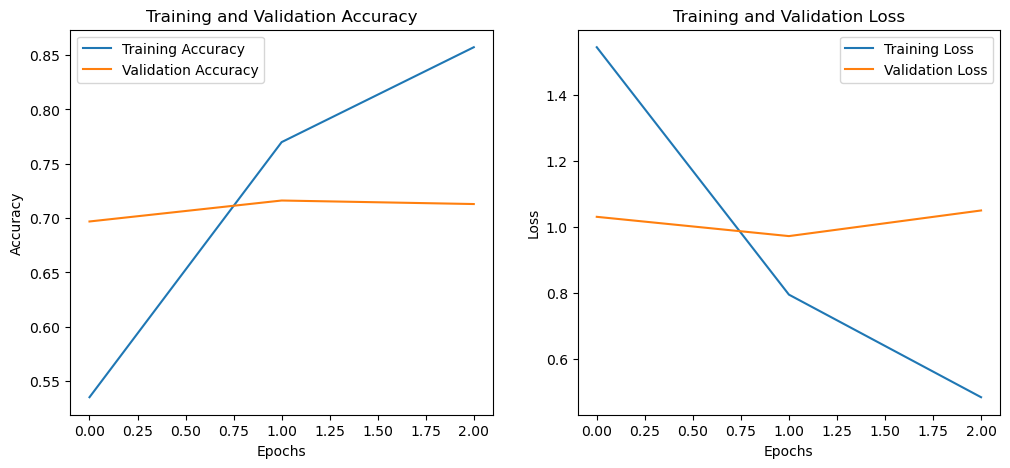

In [26]:
def plot_learning_curves(history):
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_learning_curves(history_5)

<div dir="rtl">سنحاول تجنب الـ overfit من خلال تقليل عدد الفلاتر إلى 64 الذي يؤثر على استخراج الـ features من البيانات وسنقوم بزيادة الـ dropout الى 0.5<div>

In [40]:
model_6 = Sequential()
model_6.add(Embedding(input_dim=vocab_size, output_dim=vector_size, input_length=max_length, weights=[word_vectors_matrix], trainable=True))
model_6.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
model_6.add(GlobalMaxPooling1D())
model_6.add(Dropout(0.5)) 
model_6.add(Dense(units=64, activation='relu'))
model_6.add(Dropout(0.5)) 
model_6.add(Dense(units=num_classes, activation='softmax'))
model_6.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

In [41]:
history_6 = model_6.fit(X_train_padded, y_train_onehot,
                    validation_data=(X_validation_padded, y_validation_onehot),
                    epochs=3,  
                    batch_size=512)

Epoch 1/3
1025/1025 [==============================] - 2018s 2s/step - loss: 1.8861 - accuracy: 0.4134 - val_loss: 1.2448 - val_accuracy: 0.6331
Epoch 2/3
1025/1025 [==============================] - 2086s 2s/step - loss: 1.1988 - accuracy: 0.6424 - val_loss: 1.1174 - val_accuracy: 0.6686
Epoch 3/3
1025/1025 [==============================] - 2007s 2s/step - loss: 0.9119 - accuracy: 0.7288 - val_loss: 1.1047 - val_accuracy: 0.6819


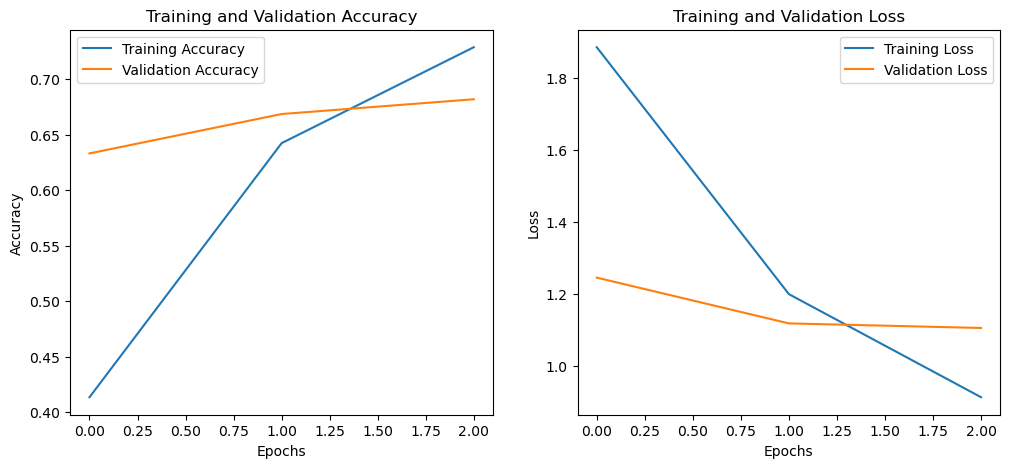

In [42]:
plot_learning_curves(history_6)

In [43]:
comparison_table = evaluate_nn_model(
    model_6,  
    X_test_padded,  
    y_test_onehot,  
    comparison_table,  
    question_step_number='5.3',  
    model_name='CNN with FastText',  
    features='Padded Sequences with FastText', 
    model_parameters='Embedding (FastText), Conv1D(filters=64), GlobalMaxPooling1D, Dense',  
    preprocessing_methods='Text Cleaning, Tokenization, Padding, FastText Embeddings'  
)

436/436 [==============================] - 3s 7ms/step


In [48]:
comparison_table = evaluate_nn_model(
    model_5,  
    X_test_padded,  
    y_test_onehot,  
    comparison_table,  
    question_step_number='5.3',  
    model_name='CNN with FastText',  
    features='Padded Sequences with FastText', 
    model_parameters='Embedding (FastText), Conv1D(filters=128), GlobalMaxPooling1D, Dense',  
    preprocessing_methods='Text Cleaning, Tokenization, Padding, FastText Embeddings'  
)

436/436 [==============================] - 5s 11ms/step


In [49]:
results = pd.DataFrame(comparison_table)
results

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,5.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D(filters=64), Glob...","Text Cleaning, Tokenization, Padding, FastText...",country,0.632662,0.595579,0.626680
1,5.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D(filters=128), Glo...","Text Cleaning, Tokenization, Padding, FastText...",country,0.666571,0.640484,0.664484


## [5.4]

<div dir="rtl">حساب مصفوفة التعارضات من اجل البلدان وعرضها بالنسبة للنموذجين السابقين<div>

In [121]:
def plot_confusion_matrix(model, X_test, y_test_onehot, label_encoder):
    # حساب التوقعات
    y_pred = model.predict(X_test)
    
    # تحويل التوقعات إلى فئات
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    # تحويل القيم الحقيقية إلى فئات (لأنها بترميز One-Hot)
    y_test_classes = np.argmax(y_test_onehot, axis=1)
    
    # أسماء الفئات
    class_names = label_encoder.classes_
    
    # حساب مصفوفة التعارضات
    cm = confusion_matrix(y_test_classes, y_pred_classes)
    
    # رسم مصفوفة التعارضات
    plt.figure(figsize=(12, 10)) 
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues', xticks_rotation=90, ax=plt.gca(), values_format='d')  # تدوير التسميات 45 درجة
    
    # إضافة التسميات
    plt.title('Confusion Matrix', fontsize=15, pad=20)  # حجم الخطوط ثابت
    plt.xlabel('Prediction', fontsize=11)  # حجم الخطوط ثابت
    plt.ylabel('Actual', fontsize=11)  # حجم الخطوط ثابت
    
    # تحريك تسميات المحور الأفقي إلى الأعلى
    plt.gca().xaxis.set_label_position('top')
    plt.gca().xaxis.tick_top()
    # ضبط المسافات بين العناصر
    plt.tight_layout()
    plt.show()

436/436 [==============================] - 13s 30ms/step


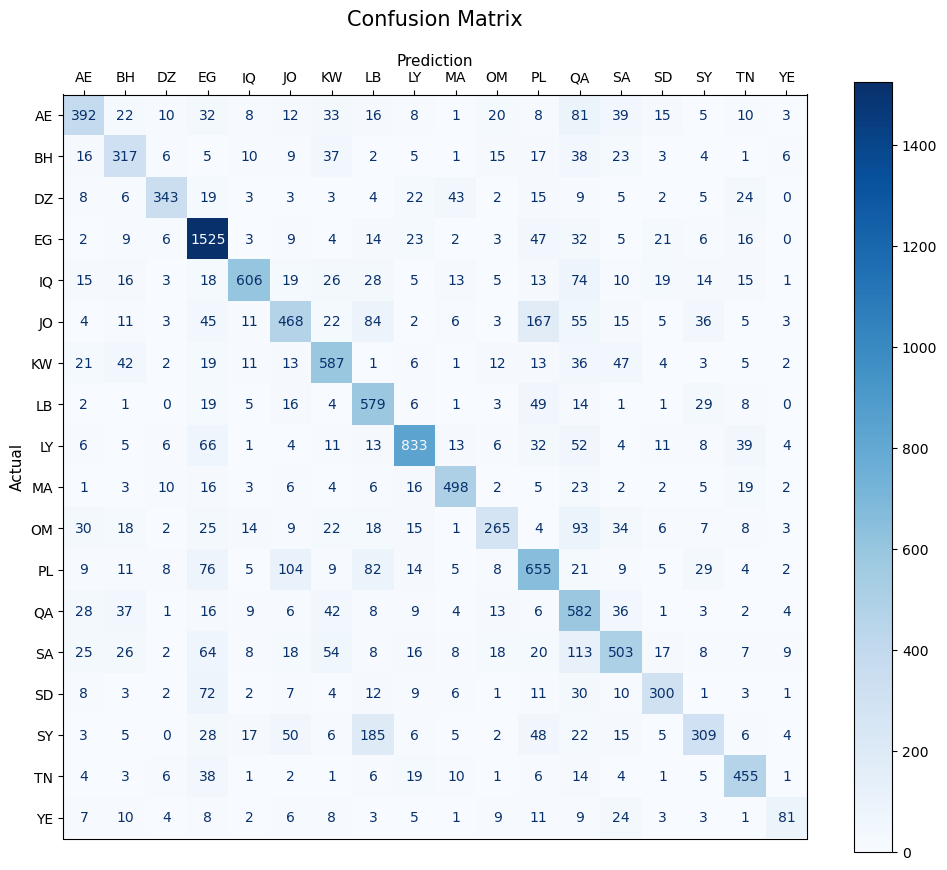

In [47]:
plot_confusion_matrix(model_5, X_test_padded, y_test_onehot, country_label_encoder)

436/436 [==============================] - 3s 7ms/step


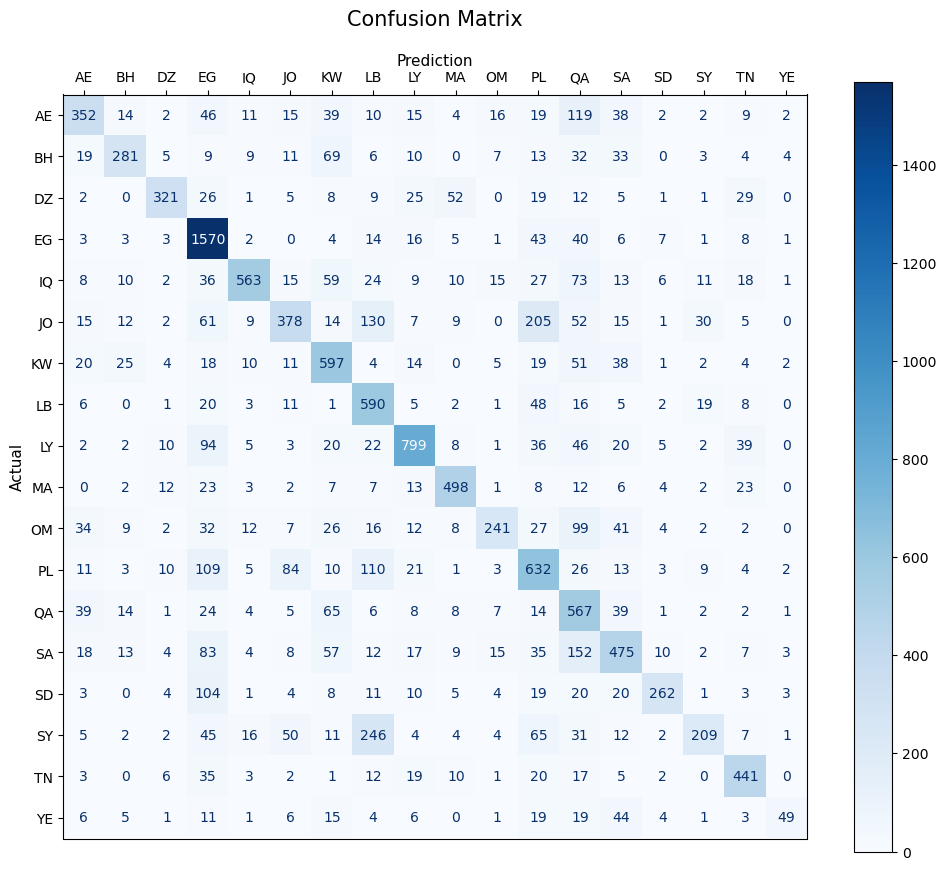

In [46]:
plot_confusion_matrix(model_6, X_test_padded, y_test_onehot, country_label_encoder)

<div dir="rtl">نرى بالمقارنة بين مصفوفتي التعارض أن النموذج الخامس الذي كان فيه عدد الفلاتر 128 والـ dropout=0.3 هو افضل من النموذج السادس لذلك سنعتمد هذه البارامترات في التدريبات اللاحقة  <div>

## [5.5]

<div dir="rtl">من نتائج تحليل التشابه بين اللهجات في الطلب الثاني تكلمنا عن امثلة من البلدان المتشابهة اللهجات وكيف أن البلدان التي لهجتها غير مميزة لم تملك عدد كلمات مميزة كثيراً وكانت نسبة التشابه بينها وبين بلدان أخرى في الـ heat_map مرتفعة<div>
<div dir="rtl">لنأخذ نفس المثال الذي تكلمنا عنه الامارات ومصر إذا نظرنا لمصفوفة التعارض نرى ان مصر تملك اكبر عدد توقعات صحيحة بين البلدان وتوقعاتها الخاطئة قليلة نسبة للتوقعات الخاطئة لبلدان اخرى بينما اذا نظرنا لنتائج الامارات التي اظهرت نسب تشابه مرتفعة مع بلدان الخليج في رسم الـ heat map نرى في مصفوفة التعارض ان اكثر توقعاتها الخاطئة هي في بلدان الخليج مثل قطر والكويت والسعودية<div>

## [5.6]

<div dir="rtl">العمل على مستوى المدن<div>

In [135]:
#البيانات من اجل المدن:
(X_train_final_city, X_test_final_city, X_validation_final_city,
 y_train_onehot_city, y_test_onehot_city, y_validation_onehot_city, city_label_encoder) = preprocess_data(
    final_train, final_test, final_validation,
    text_column='text', label_column='City',
    cleaning_functions=[normalize_arabic, clean_tweets]
)

In [136]:
#يقسم النصوص ويحولها لقيم عددية
tokenizer_city = Tokenizer()
tokenizer_city.fit_on_texts(X_train_final_city)

# حساب عدد المفردات
vocab_size = len(tokenizer_city.word_index) + 1  # +1 لأن الفهرس يبدأ من 1 وليس من 0

# تحويل النصوص إلى تسلسلات عددية
X_train_sequences = tokenizer_city.texts_to_sequences(X_train_final_city)

# حساب max_length
max_length = max(len(seq) for seq in X_train_sequences)

#عدد الفئات التي هي عدد المدن
num_classes = y_train_onehot_city.shape[1] 

In [98]:
# تحويل النصوص إلى تسلسلات عددية من اجل الحشو
X_test_sequences = tokenizer_city.texts_to_sequences(X_test_final_city)
X_validation_sequences= tokenizer_city.texts_to_sequences(X_validation_final_city)
#الحشو
X_train_padded_city = pad_sequences(X_train_sequences, maxlen=max_length)
X_test_padded_city = pad_sequences(X_test_sequences, maxlen=max_length)
X_validation_padded_city = pad_sequences(X_validation_sequences, maxlen=max_length)

In [100]:
#تحضير المصفوفة من fasttext

#إنشاء مصفوفة بالأبعاد التالية (عدد الكلمات, حجم الشعاع) 
word_vectors_matrix_city = np.zeros((vocab_size, vector_size))

#تعبئة المصفوفة باشعة الكلمات
for word, index in tokenizer_city.word_index.items():
    if word in fasttext_model:
        word_vectors_matrix_city[index] = fasttext_model[word]


In [112]:
model_7 = Sequential()
model_7.add(Embedding(input_dim=vocab_size, output_dim=vector_size, input_length=max_length, weights=[word_vectors_matrix_city], trainable=True))
model_7.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model_7.add(GlobalMaxPooling1D())
model_7.add(Dropout(0.3)) 
model_7.add(Dense(units=64, activation='relu'))
model_7.add(Dropout(0.3)) 
model_7.add(Dense(units=num_classes, activation='softmax'))
model_7.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

In [113]:
history_7 = model_7.fit(X_train_padded_city, y_train_onehot_city,
                    validation_data=(X_validation_padded_city, y_validation_onehot_city),
                    epochs=3,  
                    batch_size=128)

Epoch 1/3
744/744 [==============================] - 163s 218ms/step - loss: 1.6261 - accuracy: 0.5579 - val_loss: 1.2004 - val_accuracy: 0.6451
Epoch 2/3
744/744 [==============================] - 169s 228ms/step - loss: 0.9896 - accuracy: 0.6943 - val_loss: 1.1608 - val_accuracy: 0.6681
Epoch 3/3
744/744 [==============================] - 167s 224ms/step - loss: 0.7469 - accuracy: 0.7572 - val_loss: 1.3029 - val_accuracy: 0.6747


In [115]:
comparison_table = evaluate_nn_model(
    model_7,  
    X_test_padded_city,  
    y_test_onehot_city,  
    comparison_table,  
    question_step_number='5.6 City',  
    model_name='CNN with FastText',  
    features='Padded Sequences with FastText', 
    model_parameters='Embedding (FastText), Conv1D, GlobalMaxPooling1D, Dense',  
    preprocessing_methods='Text Cleaning, Tokenization, Padding, FastText Embeddings'  
)

162/162 [==============================] - 1s 7ms/step


In [116]:
results = pd.DataFrame(comparison_table)
results

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,5.6 City,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.447175,0.447576,0.431136


162/162 [==============================] - 1s 7ms/step


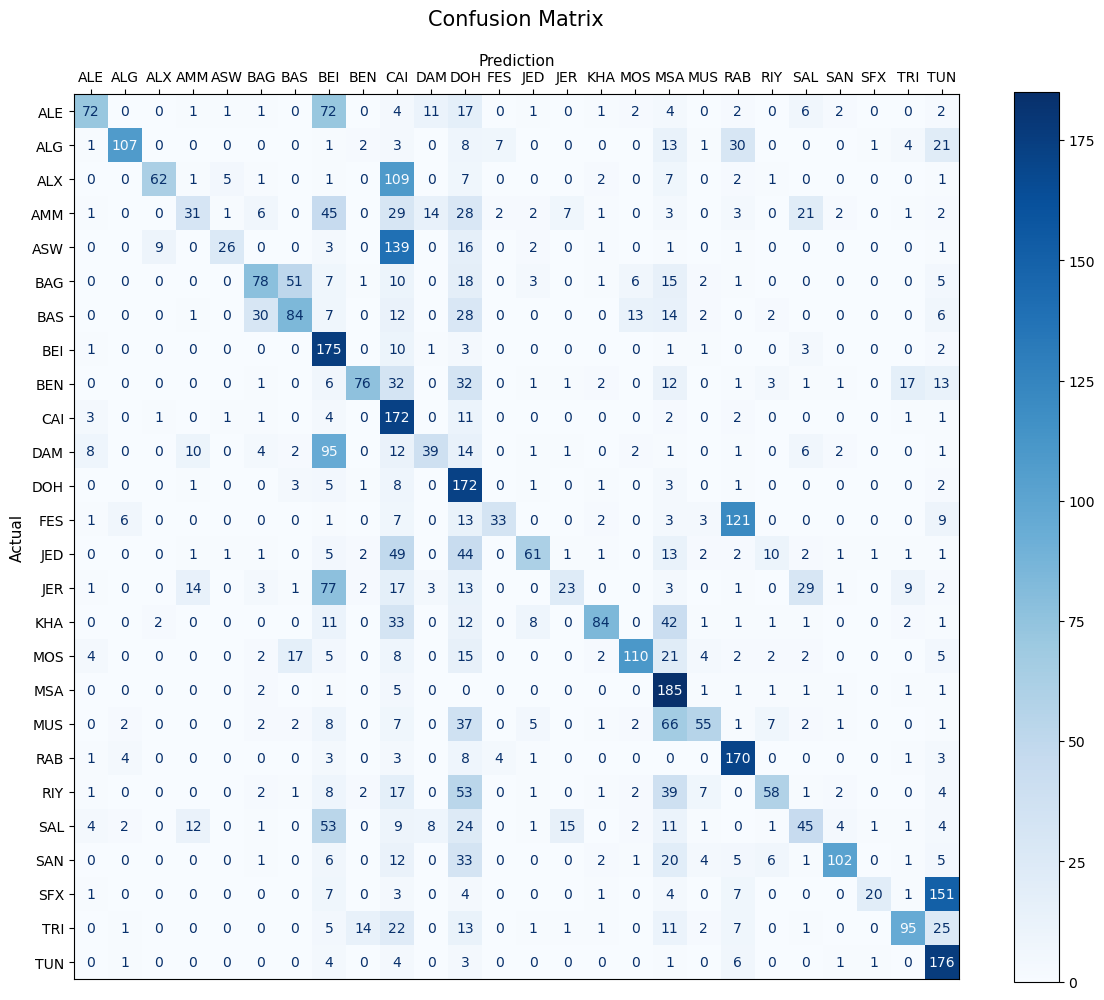

In [122]:
plot_confusion_matrix(model_7, X_test_padded_city, y_test_onehot_city, city_label_encoder)

<div dir="rtl">نلاحظ من مصفوفة تعارضات المدن ومقارنتها مع الـ heat map انه ايضاً اللهجات المتشابهة فيها توقعات خاطئة أكثر مقارنة مع غيرها مثلاً عدد التوقعات الخاطئة بين القاهرة والاسكندرية واسوان كبير لتشابه هذه اللجات<div>
<div dir="rtl">نلاحظ ايضا ان اكبر عدد من التوقعات الصحيحة كان في مدن مجموعة corpus 6 والتي تملك 12000 جملة زيادة عن باقي المدن وهي مدن الرباط وتونس والقاهرة وبيروت والدوحة اضافة الى اللغة العربية الفصحي<div>

<div dir="rtl">العمل على مستوى المناطق<div>

In [124]:
#البيانات من اجل المناطق:
(X_train_final_region, X_test_final_region, X_validation_final_region,
 y_train_onehot_region, y_test_onehot_region, y_validation_onehot_region, region_label_encoder) = preprocess_data(
    final_train, final_test, final_validation,
    text_column='text', label_column='Region',
    cleaning_functions=[normalize_arabic, clean_tweets]
)
#يقسم النصوص ويحولها لقيم عددية
tokenizer_region = Tokenizer()
tokenizer_region.fit_on_texts(X_train_final_region)

# حساب عدد المفردات
vocab_size = len(tokenizer_region.word_index) + 1  # +1 لأن الفهرس يبدأ من 1 وليس من 0

# تحويل النصوص إلى تسلسلات عددية
X_train_sequences = tokenizer_region.texts_to_sequences(X_train_final_region)

# حساب max_length
max_length = max(len(seq) for seq in X_train_sequences)

#عدد الفئات التي هي عدد المدن
num_classes = y_train_onehot_region.shape[1] 
# تحويل النصوص إلى تسلسلات عددية من اجل الحشو
X_test_sequences = tokenizer_region.texts_to_sequences(X_test_final_region)
X_validation_sequences= tokenizer_region.texts_to_sequences(X_validation_final_region)
#الحشو
X_train_padded_region = pad_sequences(X_train_sequences, maxlen=max_length)
X_test_padded_region = pad_sequences(X_test_sequences, maxlen=max_length)
X_validation_padded_region = pad_sequences(X_validation_sequences, maxlen=max_length)

#تحضير المصفوفة من fasttext

#إنشاء مصفوفة بالأبعاد التالية (عدد الكلمات, حجم الشعاع) 
word_vectors_matrix_region = np.zeros((vocab_size, vector_size))

#تعبئة المصفوفة باشعة الكلمات
for word, index in tokenizer_region.word_index.items():
    if word in fasttext_model:
        word_vectors_matrix_region[index] = fasttext_model[word]

In [126]:
model_8 = Sequential()
model_8.add(Embedding(input_dim=vocab_size, output_dim=vector_size, input_length=max_length, weights=[word_vectors_matrix_region], trainable=True))
model_8.add(Conv1D(filters=128, kernel_size=5, activation='relu'))
model_8.add(GlobalMaxPooling1D())
model_8.add(Dropout(0.3)) 
model_8.add(Dense(units=64, activation='relu'))
model_8.add(Dropout(0.3)) 
model_8.add(Dense(units=num_classes, activation='softmax'))
model_8.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',  
              metrics=['accuracy'])

In [127]:
history_8 = model_8.fit(X_train_padded_region, y_train_onehot_region,
                    validation_data=(X_validation_padded_region, y_validation_onehot_region),
                    epochs=2,  
                    batch_size=512)

Epoch 1/2
1025/1025 [==============================] - 2380s 2s/step - loss: 0.6139 - accuracy: 0.7998 - val_loss: 0.4386 - val_accuracy: 0.8475
Epoch 2/2
1025/1025 [==============================] - 2359s 2s/step - loss: 0.2676 - accuracy: 0.9154 - val_loss: 0.4489 - val_accuracy: 0.8473


In [128]:
comparison_table = evaluate_nn_model(
    model_8,  
    X_test_padded_region,  
    y_test_onehot_region,  
    comparison_table,  
    question_step_number='5.6 region',  
    model_name='CNN with FastText',  
    features='Padded Sequences with FastText', 
    model_parameters='Embedding (FastText), Conv1D, GlobalMaxPooling1D, Dense',  
    preprocessing_methods='Text Cleaning, Tokenization, Padding, FastText Embeddings'  
)

436/436 [==============================] - 5s 12ms/step


In [129]:
results = pd.DataFrame(comparison_table)
results

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,5.6 region,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.837623,0.755249,0.836562


436/436 [==============================] - 5s 11ms/step


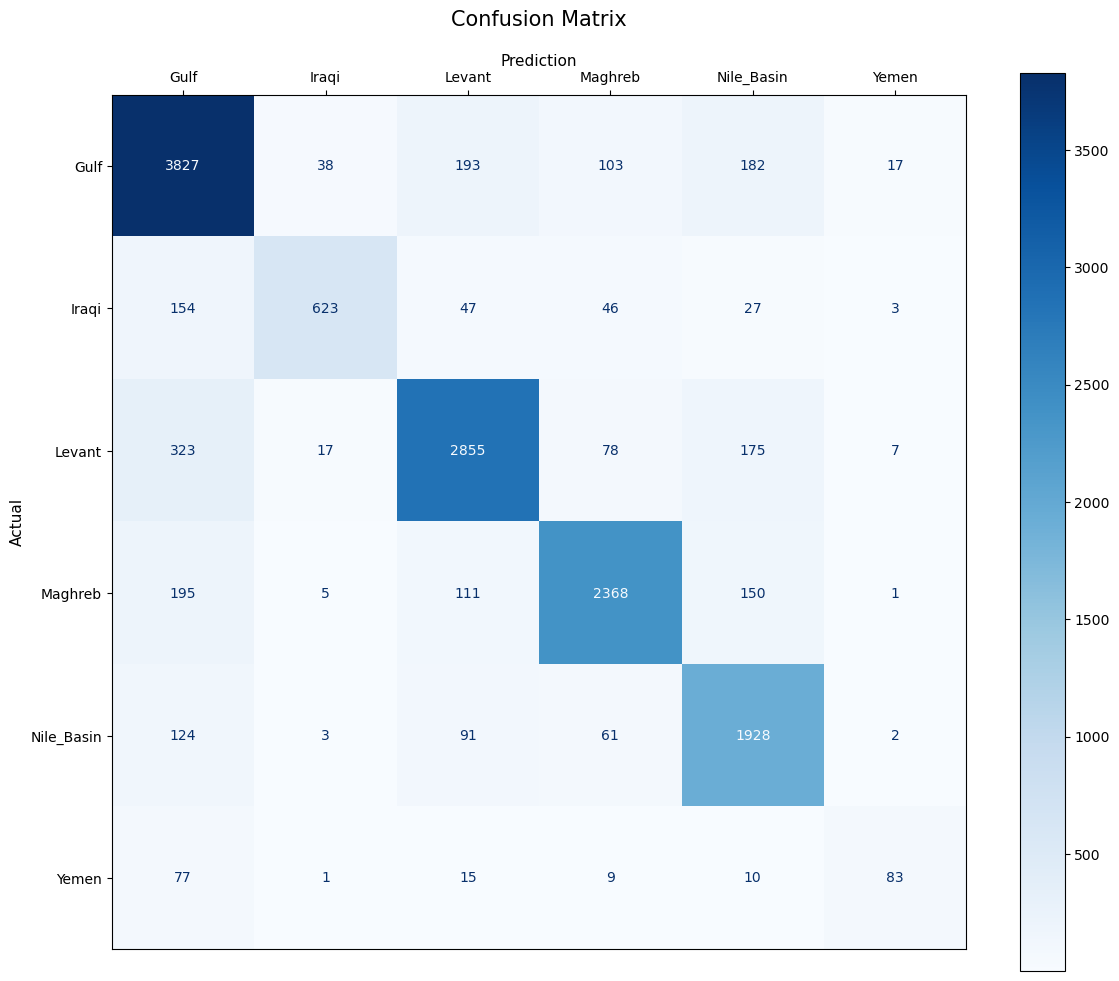

In [131]:
plot_confusion_matrix(model_8, X_test_padded_region, y_test_onehot_region, region_label_encoder)

<div dir="rtl">نلاحظ ان مشكلة تشابه اللهجات تكون اقل هنا بالمقارنة مع البلدان ولمدن وذلك لان المناطق اصلا تجمع مجموعة بلدان متشابهة<div>

# مهمة 06 : التمثيل الداللي

Semantic representation

## [6.1]

<div dir="rtl">في التابع التالي نريد ان نرسم نقاط تمثيل الكلمات المميزة لكل لهجة لذلك استخدمنا unique_words_dict وهي ديكشنري يربط كل لهجة بالكلمات المميزة الخاصة بها وقد حصلنا على هذا من حل الطلب 6.2<div>
<div dir="rtl">سنستخدم تضمينات نموذج fasttext حيث هو النموذج الافضل<div>


In [93]:
def semantic_rep(unique_words_dict, fasttext_model, level_name): #(level name=country or city or region) من اجل عنوان الرسمة
    
    # إنشاء ديكشنري ليحتوي الكلمات مع الاشعة الخاصة بها لكن مع تجاهل اللهجة التي لا تحوي كلمات فكما رأينا من نتائج الطلب 6.2 يوجد لهجات لم تحتوي على كلمات مميزة
    valid_dict = {}
    for category, words in unique_words_dict.items():
        #هنا تم وضع الشرطين اولا للتأكد من انه هناك كلمة لانه كما ذكرنا يوجد لهجات ليس لديها كلمات مميزة وللتأكد ايضا ان الكلمة موجود في النموذج 
        valid_words = [word for word in words if word and word in fasttext_model]
        if valid_words:  
            valid_dict[category] = valid_words
    
    # إذا لم يتم العثور على أي كلمات توقف
    if not valid_dict:
        return
    
    # لتجميع كل الكلمات معاً مع الاحتفاظ بمعلومات الفئة (البلد/المنطقة/المدينة)
    all_vectors = []
    all_words = []
    all_categories = []
    
    for category, words in valid_dict.items():
        for word in words:
            all_vectors.append(fasttext_model[word])
            all_words.append(word)
            all_categories.append(category)
    
    # تحويل الأشعة إلى مصفوفة
    vectors = np.array(all_vectors)
    
    # تطبيق t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    vectors_2d = tsne.fit_transform(vectors)
    
    
    plt.figure(figsize=(12, 10))
    
    # تلوين النقاط حسب الفئة (البلد/المنطقة/المدينة)
    categories = list(valid_dict.keys())
    colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)  # 60 لونًا
    
    for i, category in enumerate(categories):
        # تحديد النقاط التي تنتمي إلى هذه الفئة
        indices = [j for j, cat in enumerate(all_categories) if cat == category]
        
       #  هذا الشرط ايضا من اجل معالجة حالة لا توجد كلمات في لهجة ما
        if not indices:
            continue
        
        #رسم النقاط
        plt.scatter(vectors_2d[indices, 0], vectors_2d[indices, 1], color=colors[i], label=category, s=100, alpha=0.8)
    
    # إضافة وسيلة إيضاح خارج الرسم
    plt.title(f'Scatter Plot for Word Embeddings: {level_name}', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 12})
    plt.tight_layout()  
    plt.show()


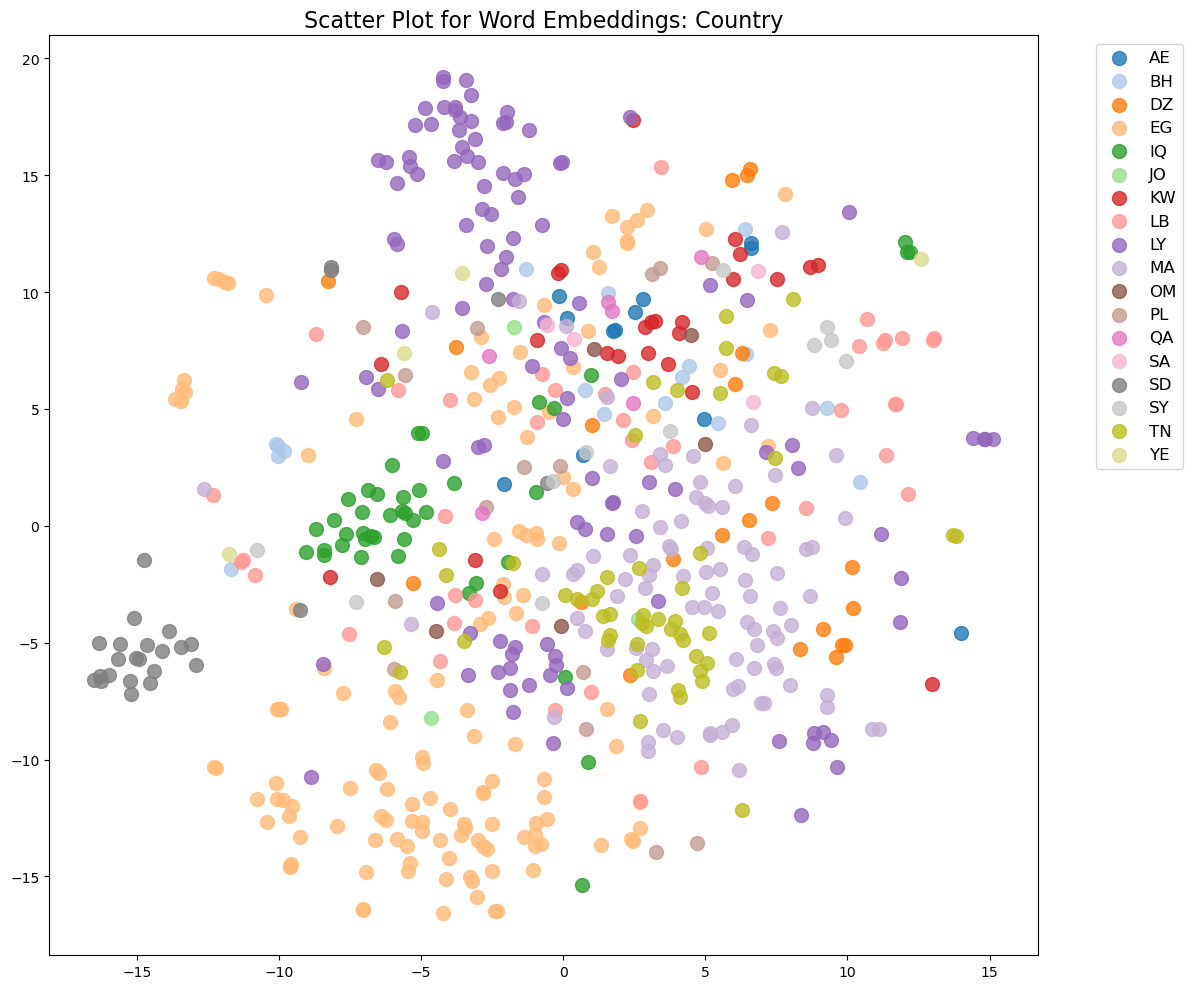

In [82]:
#مستوى البلدان
semantic_rep(unique_country_words, fasttext_model, "Country")

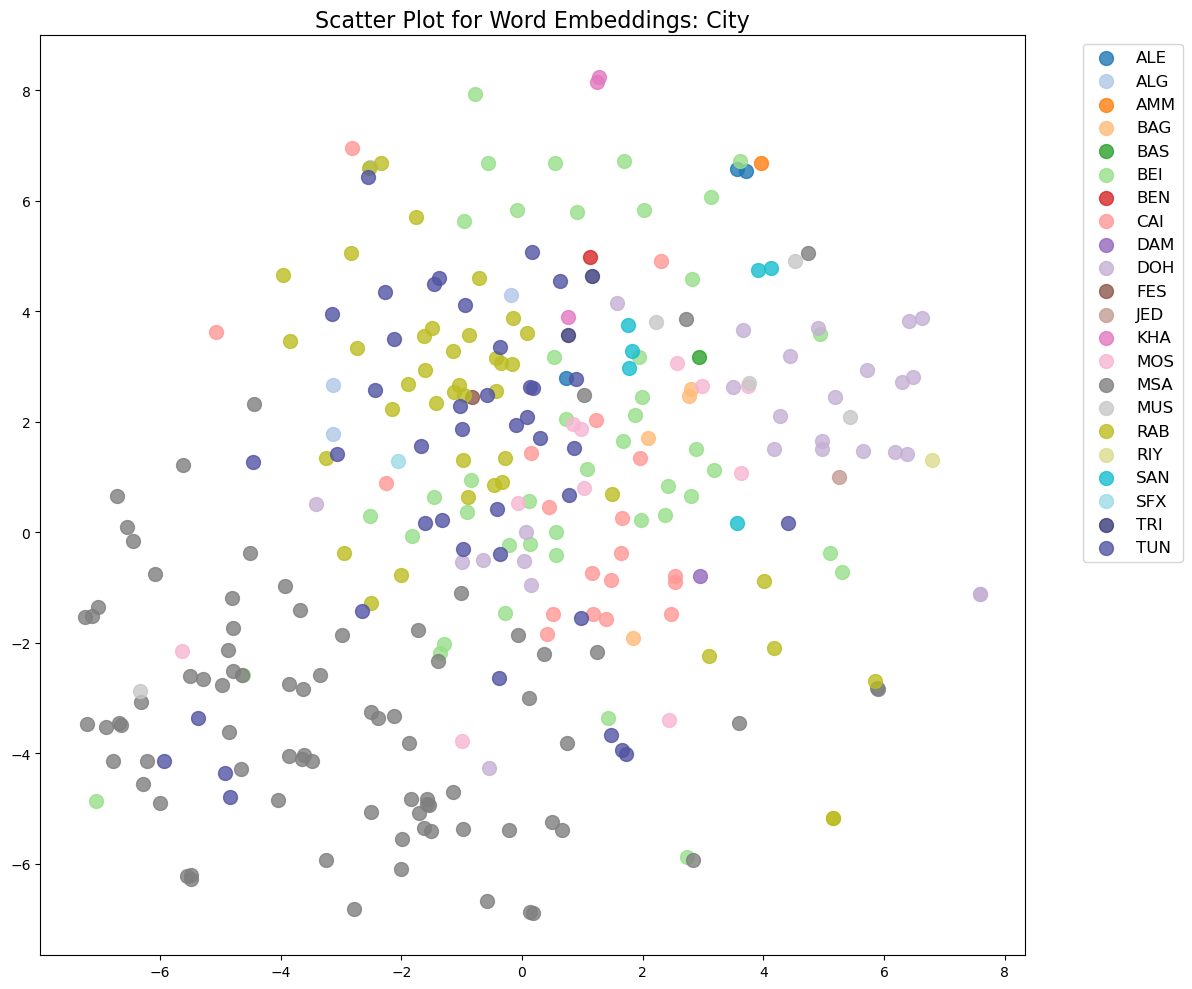

In [94]:
#مستوى المدن
semantic_rep(unique_city_words, fasttext_model, "City")

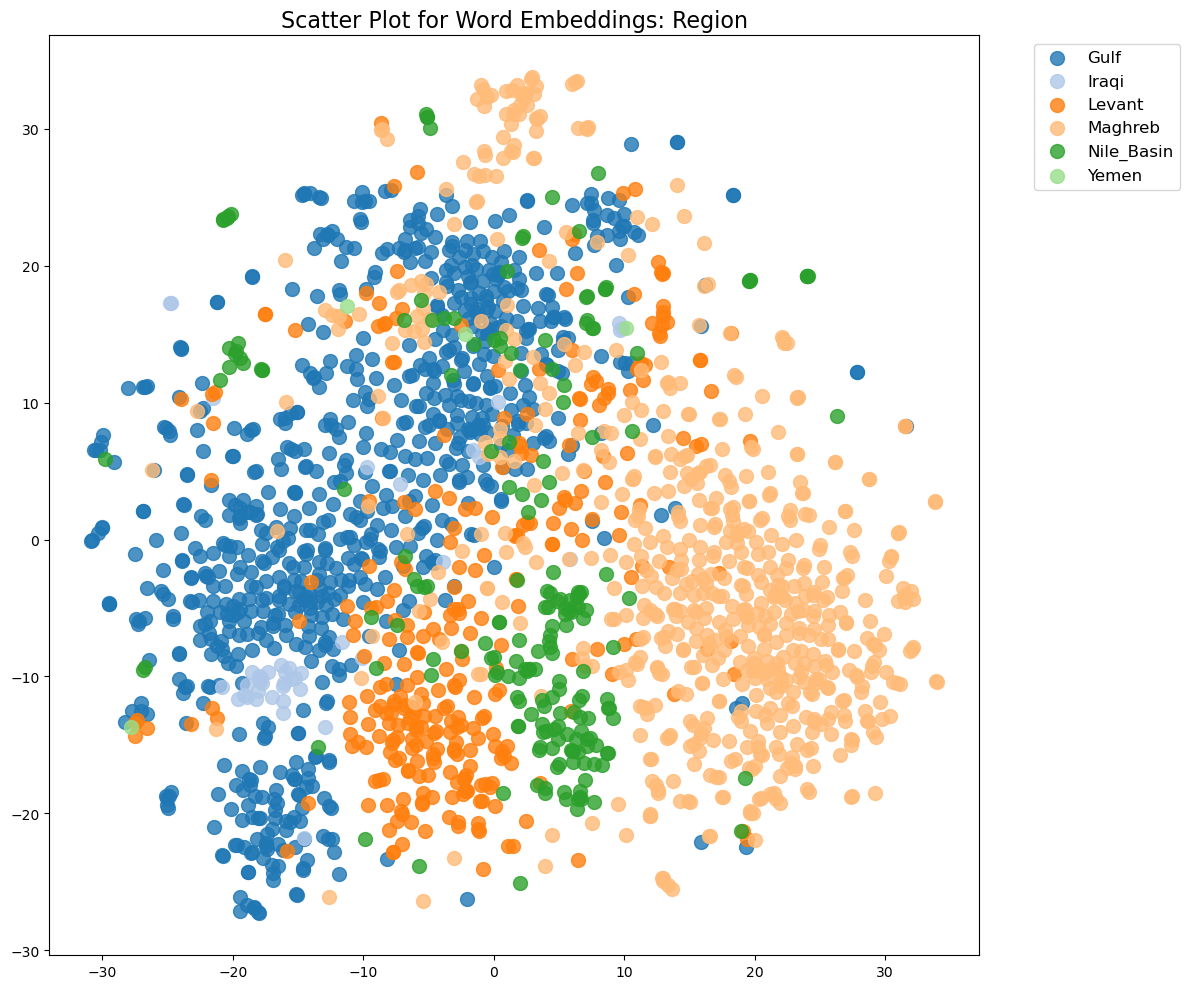

In [89]:
#مستوى المناطق
semantic_rep(unique_region_words, fasttext_model, "Region")

<div dir="rtl">الملاحظات:<div>
<div dir="rtl">نلاحظ من المخططات السابقة أن النقاط مبعثرة وليس بالضرورة ان تكون نقاط اللهجة الواحدة قريبة من بعضها وذلك لأن الرسم باستخدام الاشعة المأخوذة من fasttext تكون الكلمات قريبة من بعضها اذا كانت متقاربة بالمعنى أو بالاستخدام مثلاً<div>

## [6.2]

In [132]:
#استخراج التضمينات من كل نموذج
#البلدان:
embedding_weights_country = model_5.layers[0].get_weights()[0]
#المدن:
embedding_weights_city = model_7.layers[0].get_weights()[0]
#المناطق
embedding_weights_region = model_8.layers[0].get_weights()[0]

In [142]:
# إنشاء قاموس للكلمات والأشعة المقابلة
# التحقق من وجود الكلمة في النموذج لاننا استخدمنا هذا النموذج مسبقا في بناء اوزان طبقة التضمين ولم نضع اشعة الكلمات غير الموجودة في النموذج
word_to_embedding_country = {
    word: embedding_weights_country[index]
    for word, index in tokenizer_country.word_index.items()
    if word in fasttext_model  
}

word_to_embedding_city = {
    word: embedding_weights_city[index]
    for word, index in tokenizer_city.word_index.items()
    if word in fasttext_model 
}

word_to_embedding_region = {
    word: embedding_weights_region[index]
    for word, index in tokenizer_region.word_index.items()
    if word in fasttext_model  
}

In [143]:
def semantic_rep2(unique_words_dict, word_to_embedding, level_name):
    # إنشاء ديكشنري ليحتوي الكلمات مع الأشعة الخاصة بها
    valid_dict = {}
    for category, words in unique_words_dict.items():
        # التأكد من أن الكلمة ليست فارغة وأنها موجودة في التضمينات
        valid_words = [word for word in words if word and word in word_to_embedding]
        if valid_words:  
            valid_dict[category] = valid_words
    
    # إذا لم يتم العثور على أي كلمات توقف
    if not valid_dict:
        return
    
    # تجميع كل الكلمات معًا مع الاحتفاظ بمعلومات الفئة (البلد/المنطقة/المدينة)
    all_vectors = []
    all_words = []
    all_categories = []
    
    for category, words in valid_dict.items():
        for word in words:
            all_vectors.append(word_to_embedding[word])
            all_words.append(word)
            all_categories.append(category)
    
    # تحويل الأشعة إلى مصفوفة
    vectors = np.array(all_vectors)
    
    # تطبيق t-SNE
    tsne = TSNE(n_components=2, random_state=0)
    vectors_2d = tsne.fit_transform(vectors)
    
    # إنشاء الرسم البياني
    plt.figure(figsize=(12, 10))
    
    # تلوين النقاط حسب الفئة (البلد/المنطقة/المدينة)
    categories = list(valid_dict.keys())
    colors = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors)  # 60 لونًا
    
    for i, category in enumerate(categories):
        # تحديد النقاط التي تنتمي إلى هذه الفئة
        indices = [j for j, cat in enumerate(all_categories) if cat == category]
        
        # إذا لم توجد كلمات صالحة لهذه الفئة، تخطى
        if not indices:
            continue
        
        # رسم النقاط
        plt.scatter(vectors_2d[indices, 0], vectors_2d[indices, 1], color=colors[i], label=category, s=100, alpha=0.8)
    
    # إضافة وسيلة إيضاح خارج الرسم
    plt.title(f'Scatter Plot for Word Embeddings: {level_name}', fontsize=16)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', prop={'size': 12})
    plt.tight_layout()  
    plt.show()



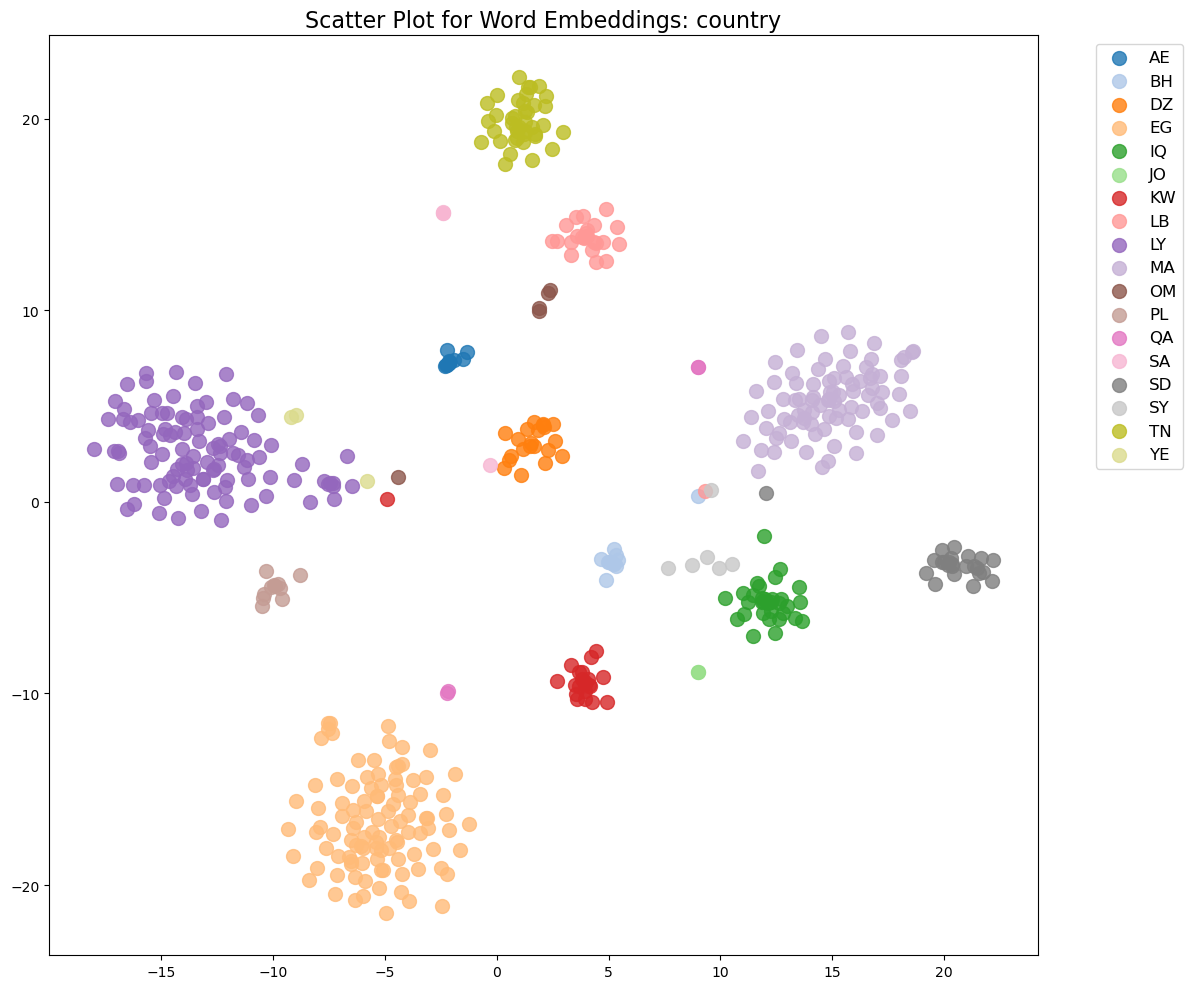

In [144]:
semantic_rep2(unique_country_words, word_to_embedding_country, "country")

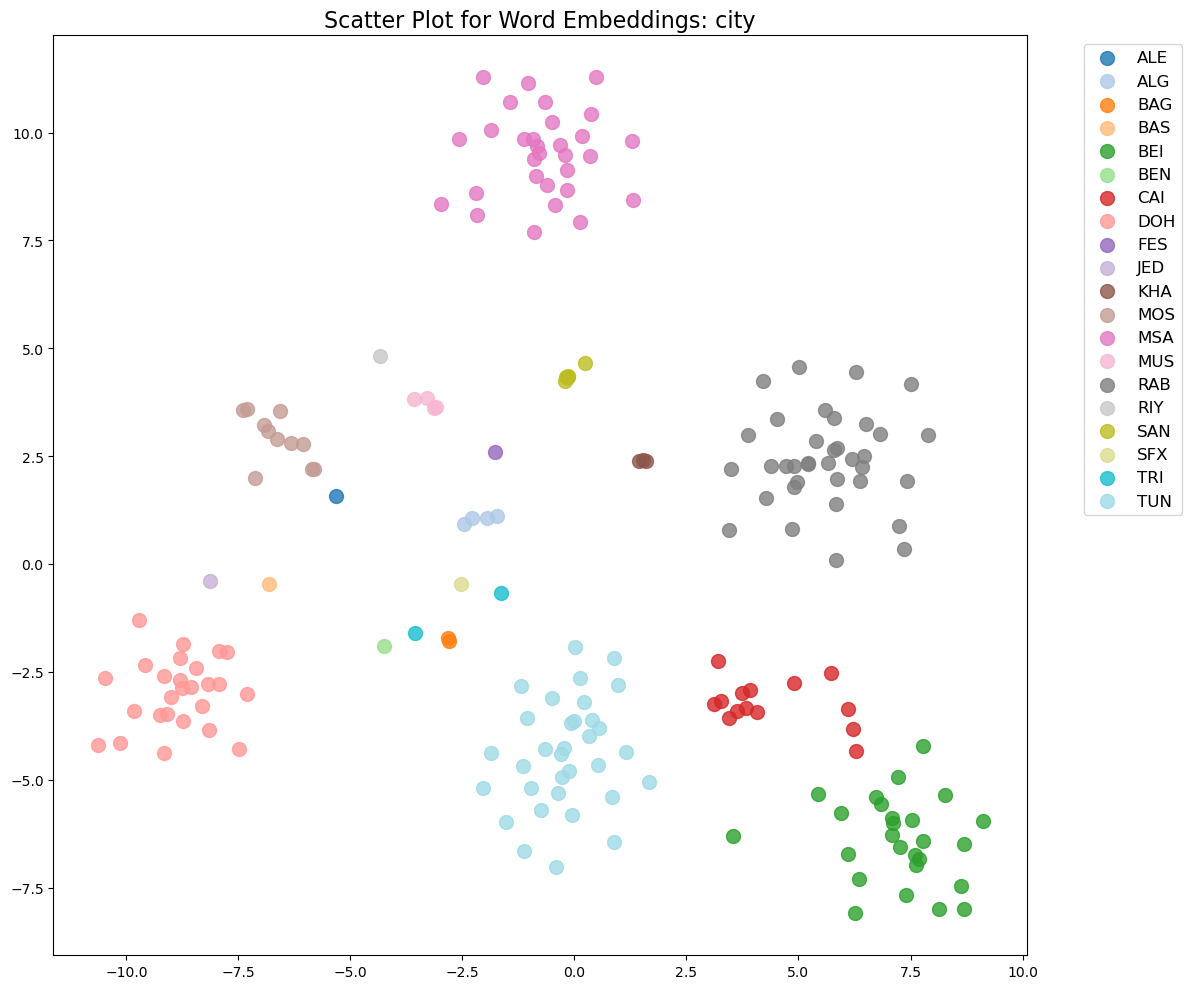

In [145]:
semantic_rep2(unique_city_words, word_to_embedding_city, "city")

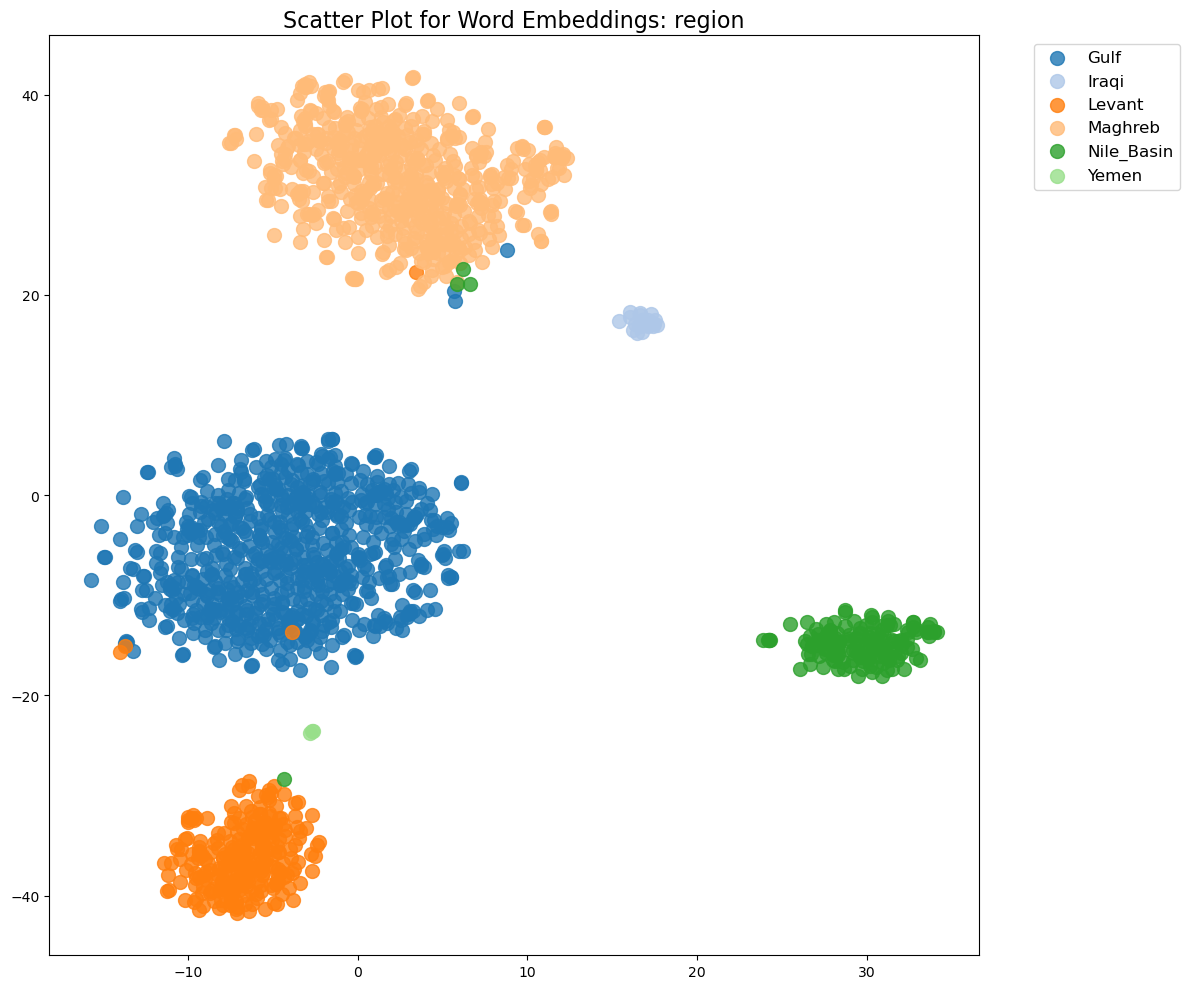

In [146]:
semantic_rep2(unique_region_words, word_to_embedding_region, "region")

<div dir="rtl">ملاحظات:<div>
<div dir="rtl">في المخططات السابقة استخدمنا مصفوفة الاشعة الناتجة عن تدريب نماذج على تصنيف اللهجات <div>
<div dir="rtl">نلاحظ أن النقاط أصبحت تتجمع بحسب اللهجات اي كلمات اللهجة الواحدة ترسم بالقرب من بعضها وتختلف دقة الرسم باختلاف دقة النماذج مثلاً أفضل رسم حصلنا عليه هو على مستوى المناطق وذلك لأن أعلى دقة كانت هي دقة النموذج الذي دربناه على مستوى المناطق وهذا لأن مشكلة تشابه اللهجات تكون أقل على مستوى المناطق وذلك لأن كل منطقة هي تجمع لأكثر من بلد تحوي أشياء مشتركة مثل اللهجة 

# Results

***<div dir="rtl">نتائج مودل multinomial NB والتي هي على الترتيب:<div>***
<div dir="rtl"> 1) تدريب على المستويات الثلاثة بدون تنظيف للبيانات<div>
<div dir="rtl"> 2) تدريب على المستويات الثلاثة بعملية تنظيف وحيدة وهي حذف الـ stop words<div>
<div dir="rtl"> 3) تدريب على المستويات الثلاثة بعملية تنظيف وحيدة وهي توحيد شكل النصوص العربية<div>
<div dir="rtl"> 4) تدريب على المستويات الثلاثة بعملية تنظيف وحيدة وهي تنظيف التغريدات بحذف الاشياء مثل الروابط والرموز والرموز التعبيرية وعلامات الترقيم<div>
<div dir="rtl"> 5) تدريب على المستويات الثلاثة بعمليات التنظيف التي حسنت الاداء وهما توحيد النصوص وتنظيف التغريدات<div>
<div dir="rtl"> 6) التدريب بعد ضبط معاملات tfidf وهي : sublinear_tf=Trueو min_df=10و ngram_range=(1, 2)و max_features=20000<div>
<div dir="rtl"> 7) التدريب بعد ابقاء معاملات tfidf فقط ngram_range=(1, 2)و max_features=20000 وهو ما حصلنا به على أعلى نتيجة<div>

In [147]:
df = pd.read_csv('machine.csv')
df

,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,4.3,MultinomialNB,TF-IDF,alpha=0.1,NaN,City,0.712432,0.248255,0.639721
1,4.3,MultinomialNB,TF-IDF,alpha=0.1,NaN,Country,0.496650,0.457028,0.478109
2,4.3,MultinomialNB,TF-IDF,alpha=0.1,NaN,Region,0.712996,0.578974,0.705062
3,4.4,MultinomialNB,TF-IDF,alpha=0.1,delete_stop_words,City,0.706086,0.232131,0.631484
4,4.4,MultinomialNB,TF-IDF,alpha=0.1,delete_stop_words,Country,0.481701,0.438533,0.462243
5,4.4,MultinomialNB,TF-IDF,alpha=0.1,delete_stop_words,Region,0.704252,0.554295,0.696442
6,4.4,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic,City,0.705028,0.229173,0.627232
7,4.4,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic,Country,0.493195,0.450921,0.473473
8,4.4,MultinomialNB,TF-IDF,alpha=0.1,normalize_arabic,Region,0.713842,0.576394,0.706629
9,4.4,MultinomialNB,TF-IDF,alpha=0.1,clean_tweets,City,0.711797,0.246588,0.638581


***<div dir="rtl">نتائج deep NNs والتي هي على الترتيب:<div>***
<div dir="rtl"> 1) تدريب deep NN<div>
<div dir="rtl"> 2) تدريب CNN بدون تهيئة مسبقة<div>
<div dir="rtl"> 3) تدريب CNN مع تهيئة مسبقة وهي تضمينات الـ fasttext لكن مع تجميد طبقة التضمين<div>
<div dir="rtl"> 4) تدريب CNN مع تهيئة مسبقة والسماح لطبقة التضمين بالتعديل أثناء التدريب ووجدنا انه الافضل<div>
<div dir="rtl"> 5) محاولة ضبط معاملات النموذج بزيادة عدد الـ epochs الى 3 مع الابقاء على عدد الفلاتر 128 والـ dropout=0.3 ولاحظنا انه الافضل<div>
<div dir="rtl"> 6) محاولة ضبط معاملات النموذج بتقليل عدد الفلاتر وزيدة الـ dropout الى 0.5 لتجنب حدوث overfit <div>
<div dir="rtl"> 7) التدريب بأفضل معاملات على مستوى المدن<div>
<div dir="rtl"> 8) التدريب بأفضل معاملات على مستوى المناطق<div>

In [149]:
df1 = pd.read_csv('deepNNs.csv')
df1

,Unnamed: 0,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score
0,0,5.1,DeepNN,TF-IDF,"3 layers, 512-256-128","Text Cleaning, delete empty rows",country,0.371424,0.321356,0.343485
1,1,5.2.1,CNN,Padded Sequences,"Embedding, Conv1D, GlobalMaxPooling1D, Dense","Text Cleaning, Tokenization, Padding",country,0.657180,0.626798,0.652532
2,2,5.2.2,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.443759,0.383978,0.406302
3,3,5.2.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.670729,0.639717,0.666212
4,4,5.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D(filters=64), Glob...","Text Cleaning, Tokenization, Padding, FastText...",country,0.632662,0.595579,0.626680
5,5,5.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D(filters=128), Glo...","Text Cleaning, Tokenization, Padding, FastText...",country,0.666571,0.640484,0.664484
6,6,5.6 City,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.447175,0.447576,0.431136
7,7,5.6 region,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.837623,0.755249,0.836562


# Final Results

In [155]:
best=pd.read_csv('best_models.csv')
best

,Unnamed: 0.1,question_step_number,model_name,features,model_parameters,preprocessing_methods,target,accuracy,balance_accuracy,f1_score,Unnamed: 0
0,18,4.6,MultinomialNB,"TF-IDF(max_features=20000, ngram_range=(1, 2)",alpha=0.1,normalize_arabic&&clean_tweets,City,0.714054,0.252333,0.643547,NaN
1,19,4.6,MultinomialNB,"TF-IDF(max_features=20000, ngram_range=(1, 2)",alpha=0.1,normalize_arabic&&clean_tweets,Country,0.540653,0.502795,0.527339,NaN
2,20,4.6,MultinomialNB,"TF-IDF(max_features=20000, ngram_range=(1, 2)",alpha=0.1,normalize_arabic&&clean_tweets,Region,0.740427,0.601848,0.734129,NaN
3,21,5.1,DeepNN,TF-IDF,"3 layers, 512-256-128","Text Cleaning, delete empty rows",country,0.371424,0.321356,0.343485,0.0
4,24,5.2.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.670729,0.639717,0.666212,3.0
5,26,5.3,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D(filters=128), Glo...","Text Cleaning, Tokenization, Padding, FastText...",country,0.666571,0.640484,0.664484,5.0
6,27,5.6 City,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.447175,0.447576,0.431136,6.0
7,28,5.6 region,CNN with FastText,Padded Sequences with FastText,"Embedding (FastText), Conv1D, GlobalMaxPooling...","Text Cleaning, Tokenization, Padding, FastText...",country,0.837623,0.755249,0.836562,7.0
